Mounted at /content/drive
Device: Tesla T4 (CUDA)
Device: cuda
Setup complete. ARM_CONFIG:
  v1: sparse_kan  (eps=0.1)
  v2: sparse_kan_v2  (eps=1e-05)
  v3: sparse_kan_v3  (eps=1e-05)
Core diagnostic functions defined.


/tmp/ipykernel_1394/2142217693.py:202: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return float(resid.var() / tot.var()), False



Configs successfully loaded per arm (out of 8 attempted):
  v1: 8
  v2: 8
  v3: 8

DEPARTURE FROM SCALED SiLU, BY LAYER AND ARM (median over LIVE edges only)
  *** This is the table that answers 'why hasn't it worked' ***
arm  layer  n_edges_total  n_dead  median_departure_live  p90_departure_live
 v1      0          13592      12               0.002188            0.120642
 v2      0          13592       0               0.000848            0.099118
 v3      0          13592       2               0.000509            0.058445
 v1      1           2648     240               0.001272            0.017393
 v2      1           2648       0               0.001653            0.110450
 v3      1           2648       0               0.002296            0.120150
KNOT OCCUPANCY (intervals holding >1% of data, out of 14)
                             n_occupied  frac_inside_range
arm layer                                                 
v1  layer1_input (post-bn1)       3.750                1.0
   

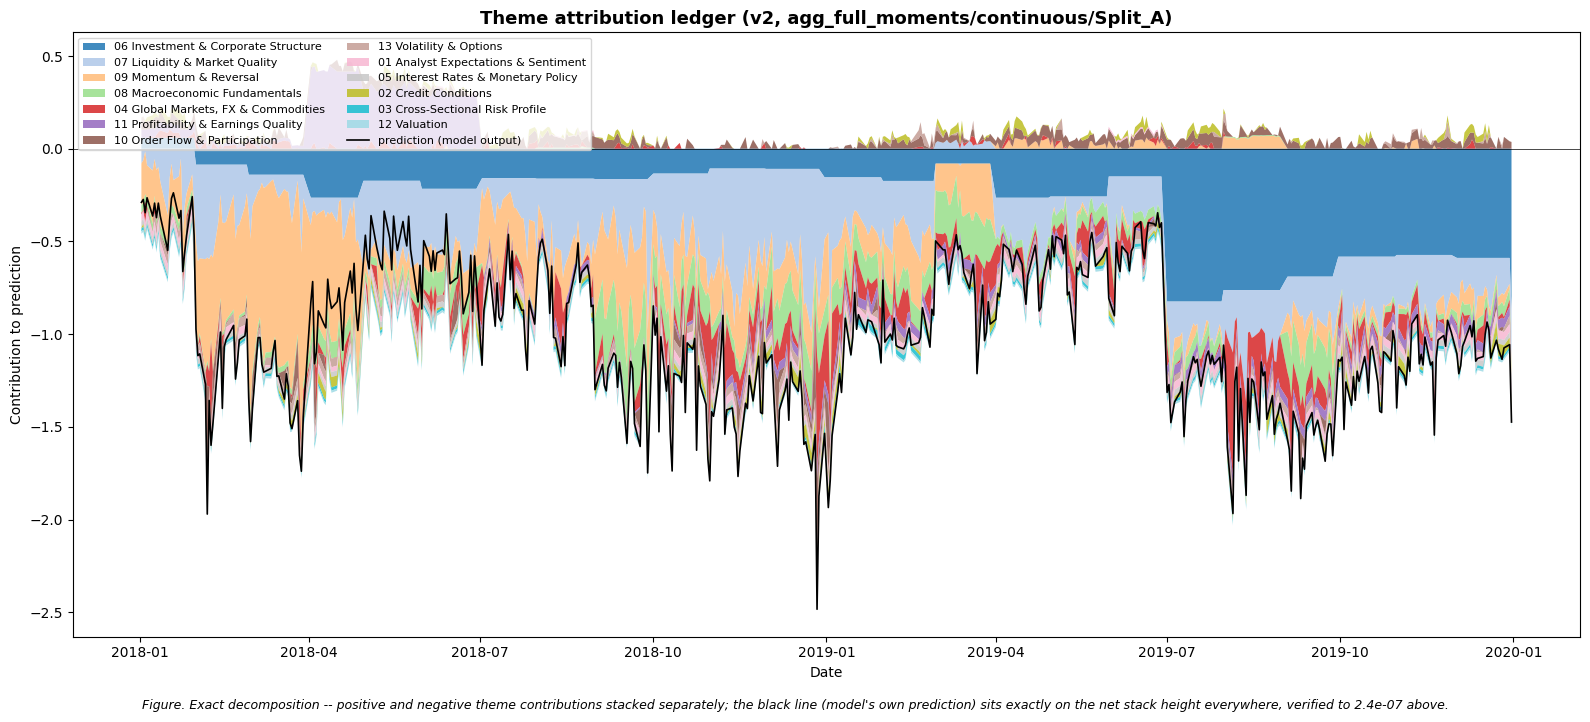

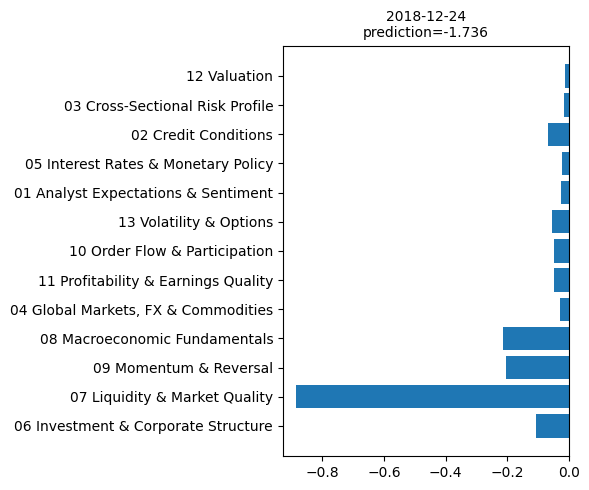

Common grid restricted to pooled 1st-99th percentile of actual post-BN theme scores: [-2.560, 2.946]
  Note: each theme's curve is evaluated on this POOLED grid, not its own individual range -- defensible since post-BN all themes have std ~= 1, but worth one sentence in the write-up.
LAYER-2 SEED STABILITY (v2, agg_full_moments/continuous/Split_A)
Median cross-seed correlation: 0.996
Per-theme median correlation:
theme
09 Momentum & Reversal                -0.999547
04 Global Markets, FX & Commodities   -0.999499
11 Profitability & Earnings Quality   -0.999173
03 Cross-Sectional Risk Profile       -0.995514
02 Credit Conditions                  -0.995450
01 Analyst Expectations & Sentiment   -0.994465
12 Valuation                          -0.985092
13 Volatility & Options               -0.605611
05 Interest Rates & Monetary Policy    0.996138
08 Macroeconomic Fundamentals          0.998828
07 Liquidity & Market Quality          0.999401
10 Order Flow & Participation          0.999592
0

In [1]:
# %% [markdown]
# # 15 — Sparse KAN Spline Interpretation
#
# Diagnostic analysis of what the KAN's spline branches are actually
# doing, across the three checkpoint arms (v1: pre-init-fix, eps=0.1;
# v2: fixed init, eps=1e-5, hyperparameters held fixed; v3: fixed init,
# eps=1e-5, hyperparameters re-searched) -- PLUS an eps-only counterfactual
# that isolates the eps effect from the init effect on v1's own weights.
#
# ═══════════════════════════════════════════════════════════════════════
# CORRECTIONS APPLIED
# ═══════════════════════════════════════════════════════════════════════
# 1. BatchNorm-aware forward pass throughout (clamp(bn(layer(x)), -5, 5)).
# 2. eps overridden per arm BEFORE load_state_dict (not in state_dict).
# 3. departure() and the seed-stability grid both evaluated on actual
#    observed data density, never a uniform full-range linspace.
# 4. B-spline basis computed ONCE per layer, per config -- not rebuilt
#    per edge from a zero-padded full-width tensor.
# 5. Dead edges recorded (not silently dropped), via TWO independent
#    definitions (output-variance-based, spline_scaler-based), compared
#    with correct per-config-then-averaged weighting (not a naive pooled
#    mean, which would silently weight by edge count -- layer 0 has
#    ~1699 edges/config, layer 1 has ~331, so a pooled mean answers a
#    different question than "average rate across configs").
# 6. Parts C/D/G merged into ONE load-and-forward-pass loop, cached in
#    a results dict keyed by (arm, dataset, target, split) -- 24
#    checkpoints loaded once, not three times, and all three tables are
#    guaranteed to describe the identical set of successfully-loaded
#    configs (relevant given v3's known missing seed-42 checkpoints).
# 7. Part F's grid-input tensor is built with .repeat() (a real copy,
#    contiguous) rather than .expand() (a non-contiguous view sharing
#    the original 200-element buffer 13 times) -- and computed once
#    outside the theme loop, not once per theme.
# 8. NEW: a v1-weights / eps-ablation cell. Loads v1's checkpoint TWICE
#    -- once at its trained eps=0.1, once with eps overridden to 1e-5 --
#    and compares layer-1 departure between the two. This isolates
#    whether v1's constrained curvature was caused by the small init
#    weights or by eps=0.1's compression, independent of v2/v3's combined
#    fix. Costs one extra checkpoint load.
#
# NOTE ON THE s.var() GUARD in departure_from_silu_fast: it is not, in
# practice, the mechanism that catches dead layer-0 edges (a z-scored
# feature's input is never near-constant), and it cannot fire at layer 1
# at all (post-BN scores cannot be near-constant by construction). It is
# retained purely as a defensive guard against the CUDA gels-only lstsq
# driver's silent garbage on rank-deficient input -- harmless, but not to
# be cited as protecting against a failure mode that can actually occur
# here. The tot.var() check is what catches genuinely dead edges.

# %% [markdown]
# ## Part A: Setup

# %%
!pip install -q git+https://github.com/Blealtan/efficient-kan.git

from google.colab import drive
drive.mount("/content/drive")

import sys
sys.path.insert(0, "/content/drive/MyDrive/Thesis/Code")

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from itertools import combinations
import contextlib
import io

from data_utils import load_split, get_device, load_theme_assignment
from sparse_kan import SparseKAN

device = get_device()
print(f"Device: {device}")

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")

BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")

OUT_DIR = BASE / "spline_interpretation"
FIG_DIR = OUT_DIR / "figures"
TABLES_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ARM_CONFIG = {
    "v1": {"results_dir": BASE / "sparse_kan",       "eps": 0.1},
    "v2": {"results_dir": BASE / "sparse_kan_v2",    "eps": 1e-5},
    "v3": {"results_dir": BASE / "sparse_kan_v3",    "eps": 1e-5},
}

GRID_SIZE, SPLINE_ORDER, GRID_RANGE = 14, 3, [-5.5, 5.5]
ROW_SUBSAMPLE_N = 2000

taxonomy_cache = {}
def get_taxonomy(dataset):
    if dataset not in taxonomy_cache:
        taxonomy_cache[dataset] = load_theme_assignment(dataset, THEMES_DIR)
    return taxonomy_cache[dataset]


def load_arm_model(arm, dataset, target_type, split_name, seed, eps_override=None, quiet=True):
    """
    Constructs a fresh SparseKAN, overrides bn1/bn2.eps to match what this
    arm actually trained under (or eps_override, for the ablation cell),
    THEN loads the checkpoint's weights.
    """
    cfg = ARM_CONFIG[arm]
    eps_to_use = eps_override if eps_override is not None else cfg["eps"]

    ckpt_path = (cfg["results_dir"] / f"seed_{seed}" / "checkpoints"
                 / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"[{arm}] checkpoint not found: {ckpt_path}")

    data = load_split(split_name, dataset, SPLITS_DIR)
    taxonomy_df = get_taxonomy(dataset)

    model = SparseKAN.from_taxonomy(
        taxonomy_df, data["feature_cols"],
        grid_size=GRID_SIZE, spline_order=SPLINE_ORDER, grid_range=GRID_RANGE,
    ).to(device)

    model.bn1.eps = eps_to_use
    model.bn2.eps = eps_to_use

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    if quiet:
        with contextlib.redirect_stdout(io.StringIO()):
            ok = model.verify_masking()
    else:
        ok = model.verify_masking()
    assert ok, f"[{arm}] masking broken on load -- investigate."

    return model, data, ckpt


print("Setup complete. ARM_CONFIG:")
for arm, cfg in ARM_CONFIG.items():
    print(f"  {arm}: {cfg['results_dir'].name}  (eps={cfg['eps']})")


# ==========================================================================
# %% [markdown]
# ## Part B: Core Diagnostic Functions

# %%
@torch.no_grad()
def forward_with_bn(model, X):
    """Exactly reproduces SparseKAN.forward()."""
    x0 = torch.nan_to_num(X, nan=0.0)
    z1_raw = model.layer0(x0)
    z1 = torch.clamp(model.bn1(z1_raw), -5.0, 5.0)
    z2_raw = model.layer1(z1)
    z2 = torch.clamp(model.bn2(z2_raw), -5.0, 5.0)
    y_hat = model.layer2(z2)
    return z1, z2, y_hat


@torch.no_grad()
def layer_bases(layer, Z_rows):
    """B-spline bases for a FIXED row subsample, computed ONCE per layer."""
    return layer.b_splines(Z_rows)


def departure_from_silu_fast(layer, p, q, B_all, Z_rows):
    """
    Fraction of an edge's output variation NOT explained by the best-fit
    scaled SiLU (the correct null, since the base branch IS a SiLU).

    The s.var() guard below is defensive against a rank-deficient least
    squares solve (CUDA's gels-only lstsq driver returns silent garbage
    on near-constant input) -- it is NOT, in practice, what catches dead
    edges here: a z-scored raw feature (layer 0's input) is never near-
    constant, and a post-BN score (layer 1's input) cannot be near-
    constant by construction. Genuinely dead edges are caught by the
    tot.var() check below instead.
    """
    z = Z_rows[:, p]
    s = F.silu(z)

    if s.var().item() < 1e-12:
        return np.nan, True  # defensive guard, not expected to fire here

    spl = B_all[:, p, :] @ layer.scaled_spline_weight[q, p, :]
    tot = layer.base_weight[q, p] * s + spl

    if tot.var().item() < 1e-12:
        return np.nan, True  # genuinely dead edge

    S = torch.stack([torch.ones_like(s), s], dim=1)
    beta = torch.linalg.lstsq(S, tot.unsqueeze(1)).solution.squeeze()
    resid = tot - S @ beta
    return float(resid.var() / tot.var()), False


def knot_occupancy(z_values, grid_range, n_knots):
    z_values = np.asarray(z_values)
    z_values = z_values[np.isfinite(z_values)]
    edges = np.linspace(grid_range[0], grid_range[1], n_knots + 1)
    counts, _ = np.histogram(z_values, bins=edges)
    frac_per_bin = counts / max(len(z_values), 1)
    n_occupied = int((frac_per_bin > 0.01).sum())
    frac_inside = float(
        ((z_values >= grid_range[0]) & (z_values <= grid_range[1])).mean()
    )
    return n_occupied, n_knots, frac_inside


print("Core diagnostic functions defined.")


# ==========================================================================
# %% [markdown]
# ## Part C: Single Load-and-Analyse Pass (Departure + Occupancy + Dead-Edges)
#
# Merged from three separate passes into one: each of the 24 checkpoints
# is loaded and forwarded exactly once, cached in RESULTS keyed by
# (arm, dataset, target, split). All three downstream tables (departure,
# knot occupancy, dead-edge cross-check) are computed from this single
# cache, guaranteeing they describe the identical set of successfully-
# loaded configs.

# %%
PROBE_CONFIGS = [
    {"dataset": "agg_full_moments", "target_type": "continuous", "seed": 42},
    {"dataset": "agg_full_moments", "target_type": "binary",     "seed": 42},
]
ALL_SPLITS = ["Split_A", "Split_B", "Split_C", "Split_D"]

RESULTS = {}   # (arm, dataset, target_type, split) -> dict of cached tensors
config_counts = {arm: 0 for arm in ARM_CONFIG}

departure_rows = []

for cfg in PROBE_CONFIGS:
    dataset, target_type, seed = cfg["dataset"], cfg["target_type"], cfg["seed"]
    for split_name in ALL_SPLITS:
        for arm in ARM_CONFIG:
            try:
                model, data, ckpt = load_arm_model(arm, dataset, target_type, split_name, seed)
            except FileNotFoundError as e:
                print(f"  skip: {e}")
                continue

            key = (arm, dataset, target_type, split_name)
            config_counts[arm] += 1

            X = torch.tensor(np.nan_to_num(data["X_train"]), dtype=torch.float32, device=device)
            rng = np.random.default_rng(hash(key) % (2**31))
            row_idx = rng.choice(len(X), size=min(ROW_SUBSAMPLE_N, len(X)), replace=False)
            row_idx_t = torch.tensor(row_idx, device=device)

            z1, z2, _ = forward_with_bn(model, X)
            X_rows = X[row_idx_t]
            z1_rows = z1[row_idx_t]

            B0 = layer_bases(model.layer0, X_rows)
            B1 = layer_bases(model.layer1, z1_rows)

            # Cache what Parts D/G/F need, so nothing is reloaded.
            RESULTS[key] = {
                "z1_np": z1.cpu().numpy(),
                "z2_np": z2.cpu().numpy(),
                "layer0_mask": model.layer0.mask.cpu().clone(),
                "layer1_mask": model.layer1.mask.cpu().clone(),
                "layer0_scaler": model.layer0.spline_scaler.data.cpu().clone(),
                "layer1_scaler": model.layer1.spline_scaler.data.cpu().clone(),
                "n_subthemes": model.n_subthemes,
                "n_themes": model.n_themes,
            }

            # ── Departure, layer 0 ──
            for q in range(model.n_subthemes):
                active_p = model.layer0.mask[q].nonzero().flatten().tolist()
                for p in active_p:
                    d, is_dead = departure_from_silu_fast(model.layer0, p, q, B0, X_rows)
                    departure_rows.append({
                        "arm": arm, "dataset": dataset, "target": target_type,
                        "split": split_name, "layer": 0,
                        "departure": d, "is_dead": is_dead,
                    })

            # ── Departure, layer 1 ──
            for t in range(model.n_themes):
                active_s = model.layer1.mask[t].nonzero().flatten().tolist()
                for s in active_s:
                    d, is_dead = departure_from_silu_fast(model.layer1, s, t, B1, z1_rows)
                    departure_rows.append({
                        "arm": arm, "dataset": dataset, "target": target_type,
                        "split": split_name, "layer": 1,
                        "departure": d, "is_dead": is_dead,
                    })

print("\nConfigs successfully loaded per arm (out of "
      f"{len(PROBE_CONFIGS) * len(ALL_SPLITS)} attempted):")
for arm, n in config_counts.items():
    print(f"  {arm}: {n}")

departure_df = pd.DataFrame(departure_rows)
departure_df.to_csv(TABLES_DIR / "departure_by_layer_arm.csv", index=False)

print("\n" + "=" * 90)
print("DEPARTURE FROM SCALED SiLU, BY LAYER AND ARM (median over LIVE edges only)")
print("  *** This is the table that answers 'why hasn't it worked' ***")
print("=" * 90)

summary_rows = []
for (arm, layer), grp in departure_df.groupby(["arm", "layer"]):
    live = grp[~grp["is_dead"]]["departure"]
    summary_rows.append({
        "arm": arm, "layer": layer,
        "n_edges_total": len(grp), "n_dead": grp["is_dead"].sum(),
        "median_departure_live": live.median() if len(live) else np.nan,
        "p90_departure_live": live.quantile(0.9) if len(live) else np.nan,
    })
summary_df = pd.DataFrame(summary_rows).sort_values(["layer", "arm"])
print(summary_df.to_string(index=False))
summary_df.to_csv(TABLES_DIR / "departure_summary.csv", index=False)


# ==========================================================================
# %% [markdown]
# ## Part D: Knot Occupancy, Layers 0 and 1, Across Arms
#
# Reads from Part C's RESULTS cache -- no reloading.

# %%
occupancy_rows = []

for key, cached in RESULTS.items():
    arm, dataset, target_type, split_name = key

    n_occ, n_total, frac_in = knot_occupancy(cached["z1_np"].flatten(), GRID_RANGE, GRID_SIZE)
    occupancy_rows.append({
        "arm": arm, "dataset": dataset, "target": target_type,
        "split": split_name, "layer": "layer1_input (post-bn1)",
        "n_occupied": n_occ, "n_total": n_total, "frac_inside_range": frac_in,
    })

    n_occ, n_total, frac_in = knot_occupancy(cached["z2_np"].flatten(), GRID_RANGE, GRID_SIZE)
    occupancy_rows.append({
        "arm": arm, "dataset": dataset, "target": target_type,
        "split": split_name, "layer": "layer2_input (post-bn2)",
        "n_occupied": n_occ, "n_total": n_total, "frac_inside_range": frac_in,
    })

occupancy_df = pd.DataFrame(occupancy_rows)
occupancy_df.to_csv(TABLES_DIR / "knot_occupancy_by_arm.csv", index=False)

print("=" * 80)
print(f"KNOT OCCUPANCY (intervals holding >1% of data, out of {GRID_SIZE})")
print("=" * 80)
print(occupancy_df.groupby(["arm", "layer"])[["n_occupied", "frac_inside_range"]]
      .mean().to_string())


# ==========================================================================
# %% [markdown]
# ## Part E: Attribution Ledger
#
# Sign-split stacking with the model's own prediction overlaid, since a
# plain stackplot cumulates negative contributions incorrectly.

# %%
LEDGER_ARM = "v2"
LEDGER_DATASET = "agg_full_moments"
LEDGER_TARGET = "continuous"
LEDGER_SPLIT = "Split_A"
LEDGER_SEED = 42

model, data, ckpt = load_arm_model(LEDGER_ARM, LEDGER_DATASET, LEDGER_TARGET,
                                    LEDGER_SPLIT, LEDGER_SEED)

X_test = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
dates_test = pd.to_datetime(data["dates_test"]).reset_index(drop=True)

with torch.no_grad():
    z1, z2, y_hat = forward_with_bn(model, X_test)

    n_themes = model.n_themes
    B2 = layer_bases(model.layer2, z2)
    theme_contrib = torch.zeros(len(X_test), n_themes, device=device)
    for t in range(n_themes):
        spl = B2[:, t, :] @ model.layer2.scaled_spline_weight[0, t, :]
        base = model.layer2.base_weight[0, t] * F.silu(z2[:, t])
        theme_contrib[:, t] = base + spl

    ledger_sum = theme_contrib.sum(dim=1)
    predicted = y_hat.squeeze(-1)

max_diff = (ledger_sum - predicted).abs().max().item()
is_close = torch.allclose(ledger_sum, predicted, atol=1e-3)
print(f"Attribution ledger identity check: max|sum(theme_contrib) - model(X)| = {max_diff:.2e}")
print(f"  {'PASS' if is_close else 'FAIL -- investigate before trusting the ledger plots'}")

# %%
theme_names = model._theme_names
theme_contrib_np = theme_contrib.cpu().numpy()
predicted_np = predicted.cpu().numpy()

order = np.argsort(-np.abs(theme_contrib_np).mean(axis=0))
cols = plt.cm.tab20(np.linspace(0, 1, len(order)))

pos = np.clip(theme_contrib_np, 0, None)
neg = np.clip(theme_contrib_np, None, 0)

fig, ax = plt.subplots(figsize=(16, 7))
ax.stackplot(dates_test, *[pos[:, i] for i in order], colors=cols, alpha=0.85,
             labels=[theme_names[i] for i in order])
ax.stackplot(dates_test, *[neg[:, i] for i in order], colors=cols, alpha=0.85)
ax.plot(dates_test, predicted_np, color="black", lw=1.2, label="prediction (model output)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Contribution to prediction")
ax.set_xlabel("Date")
ax.set_title(f"Theme attribution ledger ({LEDGER_ARM}, {LEDGER_DATASET}/{LEDGER_TARGET}/{LEDGER_SPLIT})",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.text(0.5, -0.02,
         f"Figure. Exact decomposition -- positive and negative theme "
         f"contributions stacked separately; the black line (model's own "
         f"prediction) sits exactly on the net stack height everywhere, "
         f"verified to {max_diff:.1e} above.",
         ha="center", fontsize=9, style="italic")
plt.tight_layout()
plt.savefig(FIG_DIR / f"attribution_ledger_{LEDGER_ARM}_{LEDGER_DATASET}_{LEDGER_TARGET}_{LEDGER_SPLIT}.png",
           dpi=300, bbox_inches="tight")
plt.show()

STRESS_DATES = ["2020-03-16", "2020-03-23", "2018-12-24"]
available_stress = [d for d in STRESS_DATES
                    if pd.Timestamp(d) >= dates_test.min() and pd.Timestamp(d) <= dates_test.max()]

if available_stress:
    fig, axes = plt.subplots(1, len(available_stress), figsize=(6 * len(available_stress), 5), sharey=True)
    if len(available_stress) == 1:
        axes = [axes]
    for ax, date_str in zip(axes, available_stress):
        idx = (dates_test - pd.Timestamp(date_str)).abs().idxmin()
        vals = theme_contrib_np[idx, order]
        ax.barh([theme_names[i] for i in order], vals)
        ax.axvline(0, color="k", lw=0.6)
        ax.set_title(f"{dates_test[idx].strftime('%Y-%m-%d')}\n"
                     f"prediction={predicted_np[idx]:+.3f}", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"attribution_stress_dates_{LEDGER_ARM}.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print(f"None of {STRESS_DATES} fall inside this split's test period "
          f"({dates_test.min()} to {dates_test.max()}) -- pick dates within range.")


# ==========================================================================
# %% [markdown]
# ## Part F: Seed Stability of Curve Shapes
#
# Grid restricted to the pooled 1st-99th percentile of ACTUAL post-BN
# theme scores across seeds. The grid-input tensor is built with
# .repeat() (a real, contiguous copy) rather than .expand() (a non-
# contiguous view aliasing the same 200-element buffer), and computed
# ONCE outside the theme loop, not once per theme.

# %%
STABILITY_ARM = "v2"
STABILITY_DATASET = "agg_full_moments"
STABILITY_TARGET = "continuous"
STABILITY_SPLIT = "Split_A"
STABILITY_SEEDS = [42, 123, 456]

seed_models = {}
seed_z2 = {}
for seed in STABILITY_SEEDS:
    try:
        model, data, ckpt = load_arm_model(STABILITY_ARM, STABILITY_DATASET,
                                            STABILITY_TARGET, STABILITY_SPLIT, seed)
        seed_models[seed] = model
        X = torch.tensor(np.nan_to_num(data["X_train"]), dtype=torch.float32, device=device)
        _, z2, _ = forward_with_bn(model, X)
        seed_z2[seed] = z2
    except FileNotFoundError as e:
        print(f"  skip seed {seed}: {e}")

if len(seed_models) >= 2:
    z2_pooled = torch.cat(list(seed_z2.values()))
    lo, hi = torch.quantile(z2_pooled, torch.tensor([0.01, 0.99], device=device)).tolist()
    common_grid = torch.linspace(lo, hi, 200, device=device)
    print(f"Common grid restricted to pooled 1st-99th percentile of actual "
          f"post-BN theme scores: [{lo:.3f}, {hi:.3f}]")
    print(f"  Note: each theme's curve is evaluated on this POOLED grid, not "
          f"its own individual range -- defensible since post-BN all themes "
          f"have std ~= 1, but worth one sentence in the write-up.")

    n_themes_ref = next(iter(seed_models.values())).n_themes
    theme_names_ref = next(iter(seed_models.values()))._theme_names

    # Built ONCE with .repeat() (real, contiguous copy), not .expand()
    # (non-contiguous view aliasing the same underlying buffer 13 times).
    grid_in = common_grid.unsqueeze(1).repeat(1, n_themes_ref)

    theme_curves = {seed: [] for seed in seed_models}
    for seed, model in seed_models.items():
        with torch.no_grad():
            B = layer_bases(model.layer2, grid_in)  # computed ONCE, reused across themes
            for t in range(n_themes_ref):
                spl = B[:, t, :] @ model.layer2.scaled_spline_weight[0, t, :]
                base = model.layer2.base_weight[0, t] * F.silu(common_grid)
                theme_curves[seed].append((base + spl).cpu().numpy())

    seed_list = list(seed_models.keys())
    corr_rows = []
    for t in range(n_themes_ref):
        for s1, s2 in combinations(seed_list, 2):
            c = np.corrcoef(theme_curves[s1][t], theme_curves[s2][t])[0, 1]
            corr_rows.append({"theme": theme_names_ref[t], "seed_pair": f"{s1}-{s2}", "corr": c})

    corr_df = pd.DataFrame(corr_rows)
    corr_df.to_csv(TABLES_DIR / f"seed_stability_layer2_{STABILITY_ARM}.csv", index=False)

    print("=" * 80)
    print(f"LAYER-2 SEED STABILITY ({STABILITY_ARM}, {STABILITY_DATASET}/{STABILITY_TARGET}/{STABILITY_SPLIT})")
    print("=" * 80)
    print(f"Median cross-seed correlation: {corr_df['corr'].median():.3f}")
    print(f"Per-theme median correlation:")
    print(corr_df.groupby("theme")["corr"].median().sort_values().to_string())
else:
    print(f"Fewer than 2 seeds available -- cannot compute stability.")


# ==========================================================================
# %% [markdown]
# ## Part G: Dead-Edge Cross-Check (Correctly Weighted)
#
# Compares Part C's variance-based dead-edge flag against a spline_scaler-
# based definition. Both are averaged PER-CONFIG FIRST, then averaged
# across configs -- a naive pooled mean over all rows would silently
# weight by edge count (layer 0 has ~1699 edges/config, layer 1 ~331),
# answering "rate across all edges everywhere" rather than "average rate
# across configs". These are expected to DIVERGE, not agree: a pruned
# spline_scaler kills only the spline branch -- the base branch survives,
# so the edge still shows output variance and the variance-based flag
# will not catch it. Divergence here is the expected signature of L1
# pruning the spline branch specifically, not a disagreement to resolve.

# %%
dead_edge_rows = []

for key, cached in RESULTS.items():
    arm, dataset, target_type, split_name = key

    for layer_idx, mask, scaler in [
        (0, cached["layer0_mask"], cached["layer0_scaler"]),
        (1, cached["layer1_mask"], cached["layer1_scaler"]),
    ]:
        mask_bool = mask.bool()
        active_mags = scaler.abs()[mask_bool]
        if len(active_mags) == 0:
            continue
        med = active_mags.median().item()
        if med < 1e-12:
            continue
        dead_frac = (active_mags < 0.01 * med).float().mean().item()

        dead_edge_rows.append({
            "arm": arm, "dataset": dataset, "target": target_type,
            "split": split_name, "layer": layer_idx,
            "n_active_edges": len(active_mags),
            "median_scaler_mag": med,
            "dead_edge_fraction_scaler": dead_frac,
        })

dead_df = pd.DataFrame(dead_edge_rows)
dead_df.to_csv(TABLES_DIR / "dead_edges_after_l1.csv", index=False)

print("=" * 80)
print("DEAD-EDGE FRACTION (spline_scaler-based), per-config then averaged")
print("=" * 80)
scaler_per_config_then_avg = (
    dead_df.groupby(["arm", "dataset", "target", "split", "layer"])["dead_edge_fraction_scaler"]
           .mean()
           .groupby(level=["arm", "layer"]).mean()
)
print(scaler_per_config_then_avg.to_string())

# ── Correctly-weighted cross-check: per-config first, THEN averaged ──
variance_per_config_then_avg = (
    departure_df.groupby(["arm", "dataset", "target", "split", "layer"])["is_dead"]
                .mean()
                .groupby(level=["arm", "layer"]).mean()
)

cross_check = pd.DataFrame({
    "variance_based_dead_frac": variance_per_config_then_avg,
    "scaler_based_dead_frac": scaler_per_config_then_avg,
})
print("\n" + "=" * 80)
print("CROSS-CHECK (per-config averaged, THEN averaged across configs -- "
      "NOT a naive pooled mean)")
print("  Expect scaler_based >> variance_based: L1 pruning kills the spline")
print("  branch only, the surviving base branch keeps the edge's output")
print("  variance nonzero, so the variance-based flag will not catch it.")
print("  Divergence here is expected and diagnostic, not a bug.")
print("=" * 80)
print(cross_check.to_string())
cross_check.to_csv(TABLES_DIR / "dead_edge_cross_check.csv")


# ==========================================================================
# %% [markdown]
# ## Part H: v1 eps-Only Ablation (isolates eps effect from init effect)
#
# Loads v1's checkpoint TWICE with the SAME weights: once at v1's actual
# trained eps=0.1, once with eps overridden to 1e-5. Comparing layer-1
# departure between the two isolates whether v1's constrained curvature
# was caused by the small init weights (fixed in v2/v3) or by eps=0.1's
# compression (also fixed in v2/v3, but never tested alone) -- since v2
# changed both simultaneously, this is the only place in the whole
# analysis that separates the two effects.

# %%
ABLATION_DATASET = "agg_full_moments"
ABLATION_TARGET = "continuous"
ABLATION_SPLIT = "Split_A"
ABLATION_SEED = 42

ablation_rows = []
for eps_label, eps_value in [("v1_trained_eps_0.1", 0.1), ("v1_weights_eps_1e-5", 1e-5)]:
    model, data, ckpt = load_arm_model(
        "v1", ABLATION_DATASET, ABLATION_TARGET, ABLATION_SPLIT, ABLATION_SEED,
        eps_override=eps_value,
    )

    X = torch.tensor(np.nan_to_num(data["X_train"]), dtype=torch.float32, device=device)
    rng = np.random.default_rng(0)
    row_idx = rng.choice(len(X), size=min(ROW_SUBSAMPLE_N, len(X)), replace=False)
    row_idx_t = torch.tensor(row_idx, device=device)

    z1, z2, _ = forward_with_bn(model, X)
    z1_rows = z1[row_idx_t]
    B1 = layer_bases(model.layer1, z1_rows)

    for t in range(model.n_themes):
        active_s = model.layer1.mask[t].nonzero().flatten().tolist()
        for s in active_s:
            d, is_dead = departure_from_silu_fast(model.layer1, s, t, B1, z1_rows)
            ablation_rows.append({"eps_condition": eps_label, "departure": d, "is_dead": is_dead})

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(TABLES_DIR / "v1_eps_ablation.csv", index=False)

print("=" * 80)
print(f"v1 eps-ONLY ABLATION -- SAME weights, layer-1 departure "
      f"({ABLATION_DATASET}/{ABLATION_TARGET}/{ABLATION_SPLIT}/seed{ABLATION_SEED})")
print("  Isolates: was v1's constrained curvature caused by small init")
print("  weights, or by eps=0.1's compression? v2/v3 changed both at once;")
print("  this cell is the only place that separates them.")
print("=" * 80)
print(ablation_df.groupby("eps_condition")["departure"].agg(
    ["median", lambda x: x.quantile(0.9), "count"]
).rename(columns={"<lambda_0>": "p90"}).to_string())

print("\n" + "=" * 70)
print("NOTEBOOK COMPLETE")
print("=" * 70)
print(f"  Tables:  {TABLES_DIR}")
print(f"  Figures: {FIG_DIR}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4 (CUDA)
Subtheme: 10_37 Trading Activity Intensity Shape  (34 features)


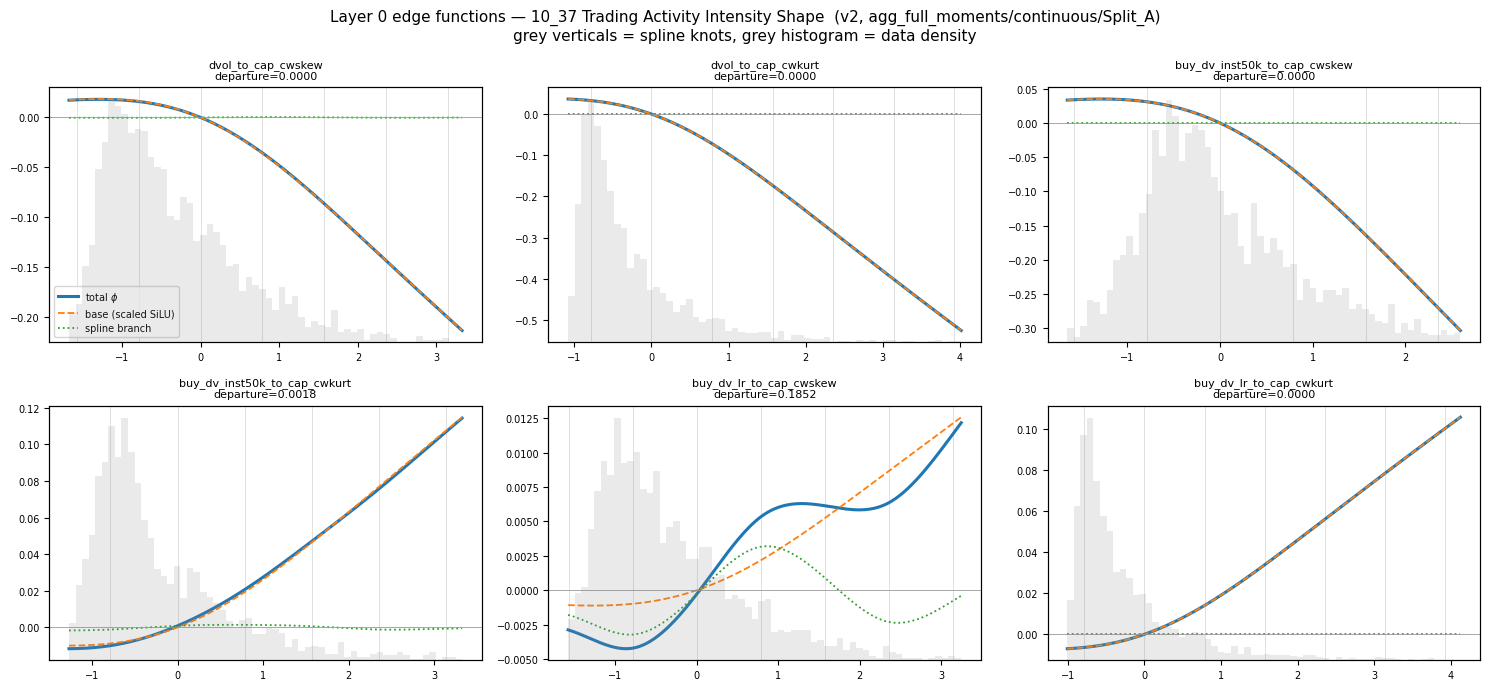

Top layer-1 edges by departure:
  0.9997  01_02 Analyst Coverage Breadth Shape       -> 01 Analyst Expectations & Se
  0.9726  06_25 Working Capital Absorption           -> 06 Investment & Corporate St
  0.8431  09_06 Mean Reversion Pressure Shape        -> 09 Momentum & Reversal
  0.8305  06_12 Equity Capital Flow Std              -> 06 Investment & Corporate St
  0.8233  08_16 Underlying Inflation Pressure        -> 08 Macroeconomic Fundamental
  0.6909  07_38 Trading-Cost Deterioration           -> 07 Liquidity & Market Qualit


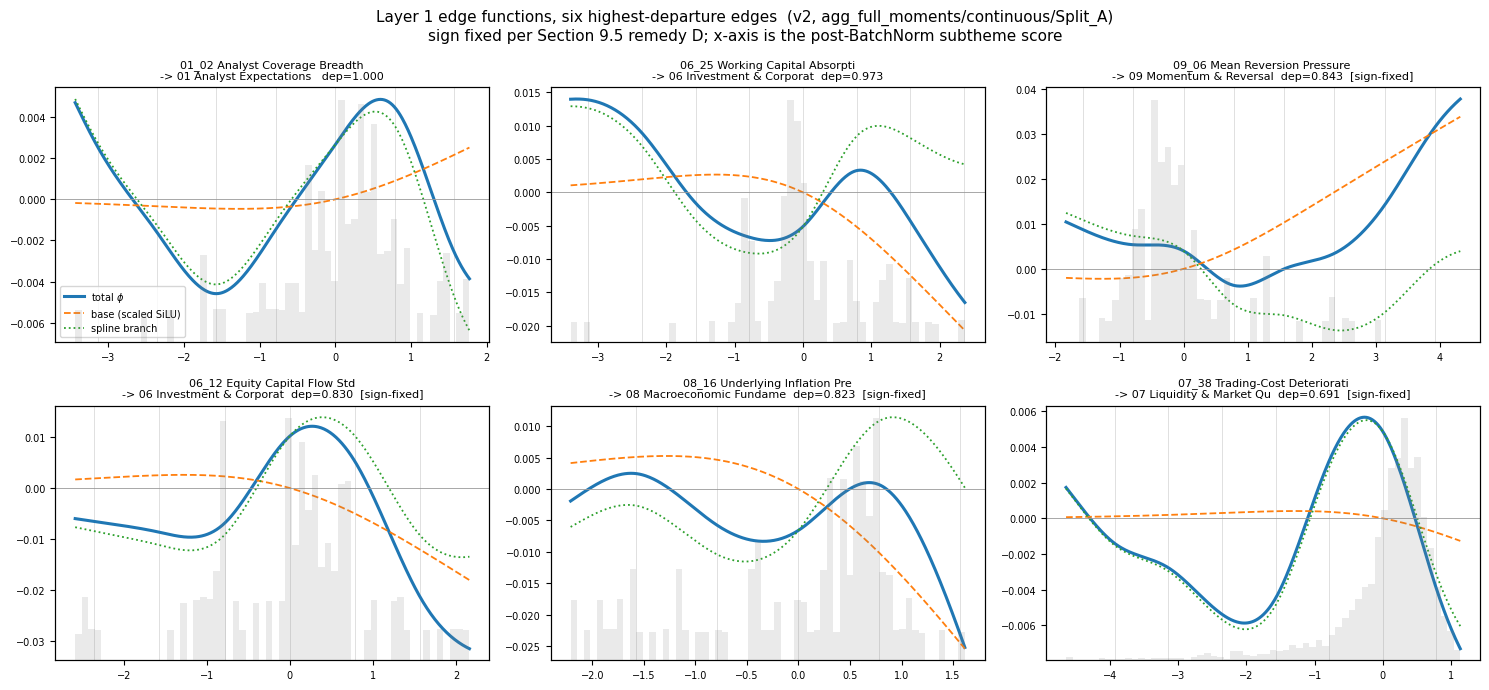

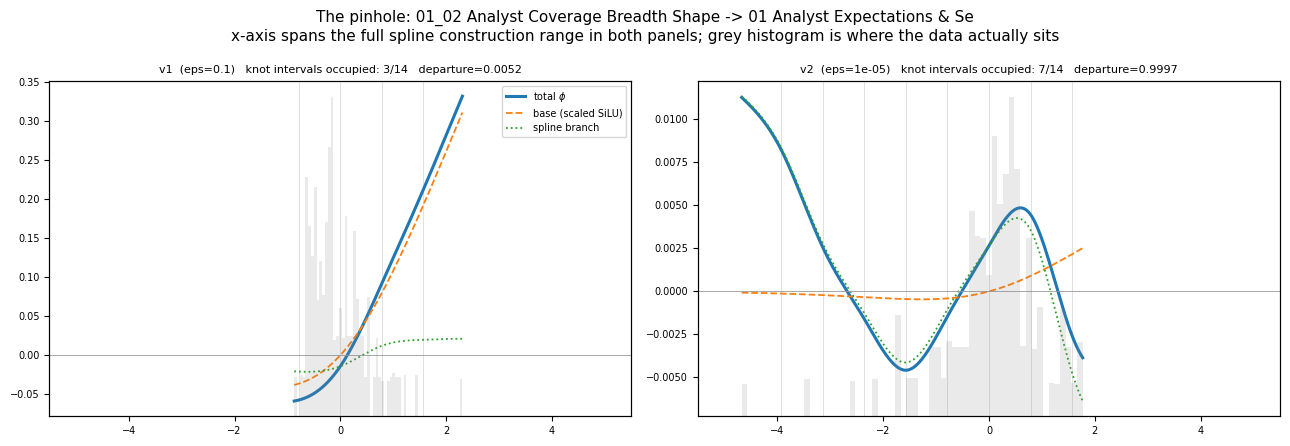

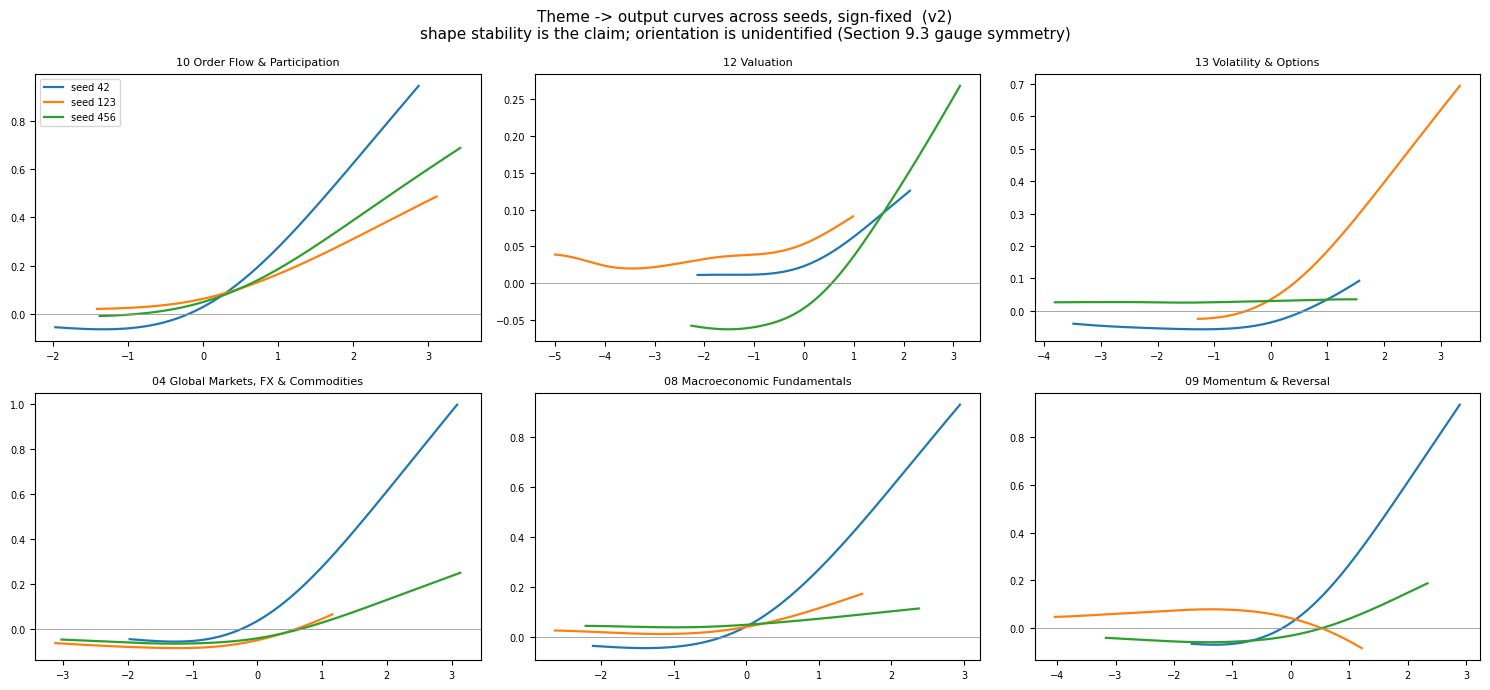


Figures saved to /content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2/spline_interpretation/figures


In [2]:
# %% [markdown]
# # 16 — Edge Function Plots (SiLU / spline / total, with data histogram)
#
# The figures the departure table is a summary statistic OF. Run AFTER
# notebook 15, or standalone (it re-defines the loaders it needs).
#
# Three figures, chosen to match what the departure numbers said:
#
#   Fig 1 — a typical LAYER-0 edge. Median departure at layer 0 is
#           0.0005 in v2, so the spline branch should be visibly flat
#           and the total should sit almost exactly on the scaled SiLU.
#           This is Section 6.7 made visual: curvature at the factor
#           level is not merely small, it is absent.
#
#   Fig 2 — the highest-departure LAYER-1 edges. p90 at layer 1 is 0.12
#           in v2/v3, so the top decile genuinely bends. These are the
#           subtheme -> theme curves worth interpreting.
#
#   Fig 3 — v1 vs v2 for the SAME layer-1 edge, showing the knot grid
#           and the data histogram. This is the pinhole figure: v1's
#           data occupies ~3.75 of 14 intervals, v2's ~6.4.
#
# CONVENTIONS (all inherited from notebook 15's corrections):
#   - eps overridden per arm before load_state_dict
#   - BatchNorm-aware forward pass
#   - x-range set from the 1st-99th percentile of ACTUAL data, never
#     the full [-5.5, 5.5] construction range
#   - SIGN CONVENTION (Section 9.5 remedy D): layer-1 and layer-2 curves
#     are plotted with the sign fixed so the curve is increasing at the
#     data median. Without this the gauge symmetry of Section 9.3 makes
#     the orientation seed-dependent and the shapes incomparable.

# %%
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
from google.colab import drive
drive.mount("/content/drive")
import sys
sys.path.insert(0, "/content/drive/MyDrive/Thesis/Code")

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import contextlib, io

from data_utils import load_split, get_device, load_theme_assignment
from sparse_kan import SparseKAN

device = get_device()

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")
BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")
FIG_DIR = BASE / "spline_interpretation" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ARM_CONFIG = {
    "v1": {"results_dir": BASE / "sparse_kan",    "eps": 0.1},
    "v2": {"results_dir": BASE / "sparse_kan_v2", "eps": 1e-5},
    "v3": {"results_dir": BASE / "sparse_kan_v3", "eps": 1e-5},
}
GRID_SIZE, SPLINE_ORDER, GRID_RANGE = 14, 3, [-5.5, 5.5]

_tax_cache = {}
def get_taxonomy(ds):
    if ds not in _tax_cache:
        _tax_cache[ds] = load_theme_assignment(ds, THEMES_DIR)
    return _tax_cache[ds]

def load_arm_model(arm, dataset, target_type, split_name, seed, eps_override=None):
    cfg = ARM_CONFIG[arm]
    eps_to_use = eps_override if eps_override is not None else cfg["eps"]
    ckpt_path = (cfg["results_dir"] / f"seed_{seed}" / "checkpoints"
                 / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"[{arm}] not found: {ckpt_path}")
    data = load_split(split_name, dataset, SPLITS_DIR)
    model = SparseKAN.from_taxonomy(
        get_taxonomy(dataset), data["feature_cols"],
        grid_size=GRID_SIZE, spline_order=SPLINE_ORDER, grid_range=GRID_RANGE,
    ).to(device)
    model.bn1.eps = eps_to_use
    model.bn2.eps = eps_to_use
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    with contextlib.redirect_stdout(io.StringIO()):
        assert model.verify_masking()
    return model, data

@torch.no_grad()
def forward_with_bn(model, X):
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(model.bn1(model.layer0(x0)), -5.0, 5.0)
    z2 = torch.clamp(model.bn2(model.layer1(z1)), -5.0, 5.0)
    return z1, z2, model.layer2(z2)


# ═══════════════════════════════════════════════════════════════════════
# THE PLOTTING PRIMITIVE
# ═══════════════════════════════════════════════════════════════════════
@torch.no_grad()
def edge_curve(layer, p, q, z):
    """Exact phi_{p,q}(z), split into base (scaled SiLU) and spline."""
    x = torch.zeros(len(z), layer.in_features, device=z.device)
    x[:, p] = z
    spl  = layer.b_splines(x)[:, p, :] @ layer.scaled_spline_weight[q, p, :]
    base = layer.base_weight[q, p] * F.silu(z)
    return (base + spl), base, spl

def knots_in_range(layer, p, lo, hi):
    k = layer.spline_order
    g = layer.grid[p, k:-k].detach().cpu().numpy()
    return g[(g >= lo) & (g <= hi)]

@torch.no_grad()
def draw_edge(ax, layer, p, q, xdata, title, fix_sign=False,
              pct=(1, 99), n=400, show_knots=True, legend=False):
    """
    One edge function with its two branches and the data histogram.

    xdata     : the ACTUAL observed inputs to this edge (1-D numpy)
    fix_sign  : Section 9.5 remedy D -- flip so the curve is increasing
                at the data median, making shapes comparable across
                seeds despite the Section 9.3 gauge symmetry.
    """
    xdata = np.asarray(xdata)
    xdata = xdata[np.isfinite(xdata)]
    lo, hi = np.percentile(xdata, pct)
    if hi - lo < 1e-9:
        ax.text(.5, .5, "degenerate input", ha="center", transform=ax.transAxes)
        return
    z = torch.linspace(float(lo), float(hi), n, device=device)
    tot, base, spl = edge_curve(layer, p, q, z)

    s = 1.0
    if fix_sign:
        mid = n // 2
        slope = (tot[min(mid + 20, n - 1)] - tot[max(mid - 20, 0)]).item()
        if slope < 0:
            s = -1.0

    zc = z.cpu().numpy()
    ax.plot(zc, s * tot.cpu().numpy(),  lw=2.2, color="tab:blue",   label=r"total $\phi$")
    ax.plot(zc, s * base.cpu().numpy(), lw=1.3, color="tab:orange", ls="--",
            label="base (scaled SiLU)")
    ax.plot(zc, s * spl.cpu().numpy(),  lw=1.3, color="tab:green",  ls=":",
            label="spline branch")

    if show_knots:
        for k in knots_in_range(layer, p, lo, hi):
            ax.axvline(k, color="0.88", lw=0.7, zorder=0)
    ax.axhline(0, color="0.6", lw=0.6)

    ax2 = ax.twinx()
    ax2.hist(xdata, bins=60, range=(lo, hi), color="grey", alpha=0.16)
    ax2.set_yticks([])

    ax.set_title(title + ("  [sign-fixed]" if s < 0 else ""), fontsize=8)
    ax.tick_params(labelsize=7)
    if legend:
        ax.legend(fontsize=7, loc="best")


# ═══════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════
DATASET, TARGET, SPLIT, SEED = "agg_full_moments", "continuous", "Split_A", 42
ARM = "v2"

model, data = load_arm_model(ARM, DATASET, TARGET, SPLIT, SEED)
X = torch.tensor(np.nan_to_num(data["X_train"]), dtype=torch.float32, device=device)
z1, z2, _ = forward_with_bn(model, X)
X_np, z1_np = X.cpu().numpy(), z1.cpu().numpy()

# Same departure measure as notebook 15, for ranking edges here.
@torch.no_grad()
def departure(layer, p, q, xdata, n_sample=2000, rng=None):
    xdata = np.asarray(xdata); xdata = xdata[np.isfinite(xdata)]
    if len(xdata) < 10: return np.nan
    rng = rng or np.random.default_rng(0)
    z = torch.tensor(rng.choice(xdata, n_sample), dtype=torch.float32, device=device)
    tot, base, spl = edge_curve(layer, p, q, z)
    s = F.silu(z)
    if tot.var().item() < 1e-12 or s.var().item() < 1e-12: return np.nan
    S = torch.stack([torch.ones_like(s), s], 1)
    beta = torch.linalg.lstsq(S, tot.unsqueeze(1)).solution.squeeze()
    return float((tot - S @ beta).var() / tot.var())


# %% [markdown]
# ## Figure 1 — Layer 0: the spline branch is essentially flat
#
# Six edges from the largest subtheme. Median layer-0 departure in v2 is
# 0.0005, so the green spline branch should be visually negligible and
# the blue total should lie on top of the orange scaled SiLU. This is
# Section 6.7 as a picture.

# %%
q_big = int(model.layer0.mask.sum(1).argmax())
feats = model.layer0.mask[q_big].nonzero().flatten().tolist()
print(f"Subtheme: {model._subtheme_names[q_big]}  ({len(feats)} features)")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (ax, p) in enumerate(zip(axes.flat, feats[:6])):
    d = departure(model.layer0, p, q_big, X_np[:, p])
    draw_edge(ax, model.layer0, p, q_big, X_np[:, p],
              f"{model._feature_names[p][:34]}\ndeparture={d:.4f}",
              legend=(i == 0))
fig.suptitle(f"Layer 0 edge functions — {model._subtheme_names[q_big][:50]}  "
             f"({ARM}, {DATASET}/{TARGET}/{SPLIT})\n"
             "grey verticals = spline knots, grey histogram = data density",
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / f"fig1_layer0_edges_{ARM}.png", dpi=300, bbox_inches="tight")
plt.show()


# %% [markdown]
# ## Figure 2 — Layer 1: the top-decile edges genuinely bend
#
# p90 departure at layer 1 is ~0.12 in v2/v3 (vs 0.017 in v1). These are
# the subtheme -> theme curves that actually carry curvature, and the
# ones worth interpreting economically.

# %%
l1_rows = []
for t in range(model.n_themes):
    for s_ in model.layer1.mask[t].nonzero().flatten().tolist():
        d = departure(model.layer1, s_, t, z1_np[:, s_])
        if np.isfinite(d):
            l1_rows.append((d, s_, t))
l1_rows.sort(reverse=True)

print("Top layer-1 edges by departure:")
for d, s_, t in l1_rows[:6]:
    print(f"  {d:.4f}  {model._subtheme_names[s_][:40]:<42} -> {model._theme_names[t][:28]}")

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for i, (ax, (d, s_, t)) in enumerate(zip(axes.flat, l1_rows[:6])):
    draw_edge(ax, model.layer1, s_, t, z1_np[:, s_],
              f"{model._subtheme_names[s_][:30]}\n-> {model._theme_names[t][:24]}  "
              f"dep={d:.3f}",
              fix_sign=True, legend=(i == 0))
fig.suptitle(f"Layer 1 edge functions, six highest-departure edges  "
             f"({ARM}, {DATASET}/{TARGET}/{SPLIT})\n"
             "sign fixed per Section 9.5 remedy D; x-axis is the post-BatchNorm subtheme score",
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / f"fig2_layer1_top_departure_{ARM}.png", dpi=300, bbox_inches="tight")
plt.show()


# %% [markdown]
# ## Figure 3 — The pinhole: v1 vs v2, same edge
#
# The methods-section figure. v1's subtheme scores occupy ~3.75 of 14
# knot intervals; v2's occupy ~6.4. Same architecture, same edge index,
# only the initialisation and eps differ.

# %%
_, s_ref, t_ref = l1_rows[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, arm in zip(axes, ["v1", "v2"]):
    try:
        m_a, d_a = load_arm_model(arm, DATASET, TARGET, SPLIT, SEED)
    except FileNotFoundError as e:
        ax.text(.5, .5, str(e), ha="center", transform=ax.transAxes); continue
    Xa = torch.tensor(np.nan_to_num(d_a["X_train"]), dtype=torch.float32, device=device)
    z1a, _, _ = forward_with_bn(m_a, Xa)
    z1a_np = z1a.cpu().numpy()[:, s_ref]

    edges = np.linspace(GRID_RANGE[0], GRID_RANGE[1], GRID_SIZE + 1)
    occ = int(((np.histogram(z1a_np, bins=edges)[0] / len(z1a_np)) > 0.01).sum())
    dep = departure(m_a.layer1, s_ref, t_ref, z1a_np)

    draw_edge(ax, m_a.layer1, s_ref, t_ref, z1a_np,
              f"{arm}  (eps={ARM_CONFIG[arm]['eps']})   "
              f"knot intervals occupied: {occ}/{GRID_SIZE}   departure={dep:.4f}",
              fix_sign=True, pct=(0.5, 99.5), legend=(arm == "v1"))
    # show the FULL construction range so the pinhole is visible
    ax.set_xlim(GRID_RANGE[0], GRID_RANGE[1])

fig.suptitle(f"The pinhole: {model._subtheme_names[s_ref][:45]} -> "
             f"{model._theme_names[t_ref][:28]}\n"
             "x-axis spans the full spline construction range in both panels; "
             "grey histogram is where the data actually sits",
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / f"fig3_pinhole_v1_vs_v2.png", dpi=300, bbox_inches="tight")
plt.show()


# %% [markdown]
# ## Figure 4 (optional) — seed stability, sign-fixed
#
# The theme curves across seeds 42/123/456, with the Section 9.5 sign
# convention applied. Notebook 15 found |corr| > 0.98 for 12 of 13
# themes once sign is accounted for; this shows that directly.

# %%
STAB_SEEDS = [42, 123, 456]
seed_ms = {}
for sd in STAB_SEEDS:
    try:
        m_s, d_s = load_arm_model(ARM, DATASET, TARGET, SPLIT, sd)
        Xs = torch.tensor(np.nan_to_num(d_s["X_train"]), dtype=torch.float32, device=device)
        _, z2s, _ = forward_with_bn(m_s, Xs)
        seed_ms[sd] = (m_s, z2s.cpu().numpy())
    except FileNotFoundError as e:
        print(f"  skip seed {sd}: {e}")

if len(seed_ms) >= 2:
    n_th = next(iter(seed_ms.values()))[0].n_themes
    names = next(iter(seed_ms.values()))[0]._theme_names
    order = np.argsort(-np.array([
        next(iter(seed_ms.values()))[1][:, t].std() for t in range(n_th)]))[:6]

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for ax, t in zip(axes.flat, order):
        for sd, (m_s, z2_np) in seed_ms.items():
            lo, hi = np.percentile(z2_np[:, t], [1, 99])
            z = torch.linspace(float(lo), float(hi), 300, device=device)
            tot, _, _ = edge_curve(m_s.layer2, t, 0, z)
            v = tot.cpu().numpy()
            mid = len(v) // 2
            if v[min(mid + 20, len(v) - 1)] - v[max(mid - 20, 0)] < 0:
                v = -v
            ax.plot(z.cpu().numpy(), v, lw=1.6, label=f"seed {sd}")
        ax.axhline(0, color="0.6", lw=0.6)
        ax.set_title(names[t][:38], fontsize=8)
        ax.tick_params(labelsize=7)
    axes.flat[0].legend(fontsize=7)
    fig.suptitle(f"Theme -> output curves across seeds, sign-fixed  ({ARM})\n"
                 "shape stability is the claim; orientation is unidentified "
                 "(Section 9.3 gauge symmetry)", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"fig4_seed_stability_curves_{ARM}.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"\nFigures saved to {FIG_DIR}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4 (CUDA)
9 reference days, predictions -2.311 to -0.020
Theorem 1 check: max|sum - yhat| = 4.77e-07

THEME CONTRIBUTIONS TO OUTPUT (exact, additive)
                              theme  sd_of_contribution  p5_p95_swing  mean_abs  share_of_total_sd
06 Investment & Corporate Structure              0.2568        0.7694    0.1467             0.1628
      10 Order Flow & Participation              0.2248        0.6554    0.1384             0.1425
             09 Momentum & Reversal              0.2181        0.6172    0.1407             0.1382
04 Global Markets, FX & Commodities              0.2166        0.5858    0.1336             0.1373
      08 Macroeconomic Fundamentals              0.1909        0.5241    0.13

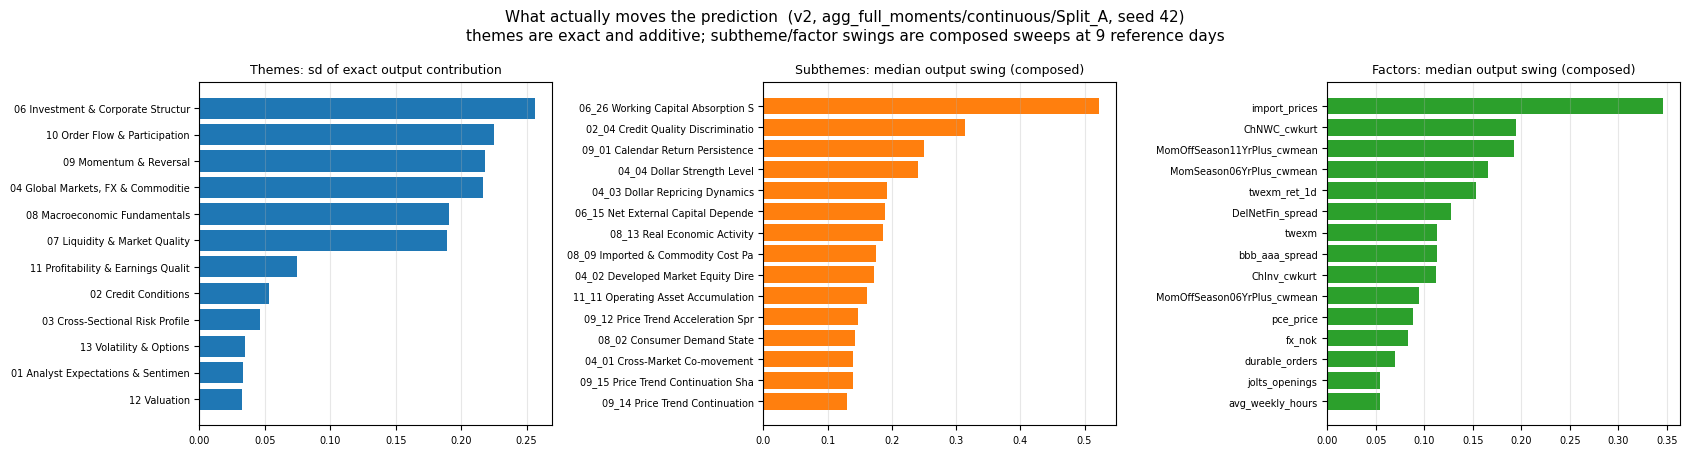


SEED STABILITY OF THEME IMPORTANCE (amplitude, not shape)
                              theme  sd_seed42  sd_seed123  sd_seed456  max_over_min
            13 Volatility & Options     0.0351      0.1422      0.0026       54.1048
      07 Liquidity & Market Quality     0.1893      0.0268      0.0144       13.1696
05 Interest Rates & Monetary Policy     0.0072      0.0542      0.0907       12.6127
      08 Macroeconomic Fundamentals     0.1909      0.0382      0.0177       10.8102
               02 Credit Conditions     0.0530      0.0158      0.1491        9.4333
             09 Momentum & Reversal     0.2181      0.0377      0.0433        5.7848
    03 Cross-Sectional Risk Profile     0.0459      0.1223      0.0245        4.9816
04 Global Markets, FX & Commodities     0.2166      0.0435      0.0570        4.9801
06 Investment & Corporate Structure     0.2568      0.1251      0.0711        3.6114
                       12 Valuation     0.0325      0.0166      0.0575        3.4531
01 Ana

In [3]:
# %% [markdown]
# # 17 — Output Contribution: what actually moves the prediction
#
# Notebook 16 plots LOCAL edge functions. Those are not contributions to
# the output: BatchNorm renormalises between every layer, and layer 2
# applies its own nonlinear map, so a layer-0 or layer-1 curve's y-axis
# says nothing about how much that quantity moves the prediction.
#
# WHAT IS AND IS NOT ADDITIVE
#
#   theme -> output   : EXACT and additive. Layer 2 is a sum of
#                       per-theme edge functions into a single output
#                       node with nothing after it, so
#                       y_hat = sum_t phi_t(z2_t) exactly (Theorem 1).
#
#   subtheme -> output: NOT additive. z2_t = clamp(bn2(sum_s phi_{s,t}(z1_s)))
#                       is affine-in-the-sum at eval (BN is a frozen
#                       per-unit affine map once model.eval() is set),
#                       but layer 2 then applies a NONLINEAR phi_t to it.
#                       So a subtheme's effect depends on where the rest
#                       of that day sits on phi_t -- this is the
#                       compounding of Theorem 3, and it is why the
#                       sweeps below are evaluated at several real days
#                       rather than at one synthetic average day.
#
#   factor -> output  : NOT additive, same reason, one layer deeper.
#
# METHOD: composed sweep. Take a real day, vary ONE quantity across its
# observed 5th-95th percentile holding that day's other values fixed,
# and record the range of the resulting change in the model's output.
# Repeat at several reference days and report the median swing.
#
# BN is frozen at eval (running statistics), so the composed map is a
# well-defined deterministic function and the sweep is valid.

# %%
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
from google.colab import drive
drive.mount("/content/drive")
import sys
sys.path.insert(0, "/content/drive/MyDrive/Thesis/Code")

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import contextlib, io

from data_utils import load_split, get_device, load_theme_assignment
from sparse_kan import SparseKAN

device = get_device()

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")
BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")
FIG_DIR   = BASE / "spline_interpretation" / "figures"
TABLE_DIR = BASE / "spline_interpretation" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True); TABLE_DIR.mkdir(parents=True, exist_ok=True)

ARM_CONFIG = {
    "v1": {"results_dir": BASE / "sparse_kan",    "eps": 0.1},
    "v2": {"results_dir": BASE / "sparse_kan_v2", "eps": 1e-5},
    "v3": {"results_dir": BASE / "sparse_kan_v3", "eps": 1e-5},
}
GRID_SIZE, SPLINE_ORDER, GRID_RANGE = 14, 3, [-5.5, 5.5]

_tax = {}
def get_taxonomy(ds):
    if ds not in _tax: _tax[ds] = load_theme_assignment(ds, THEMES_DIR)
    return _tax[ds]

def load_arm_model(arm, dataset, target_type, split_name, seed):
    cfg = ARM_CONFIG[arm]
    p = (cfg["results_dir"] / f"seed_{seed}" / "checkpoints"
         / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not p.exists(): raise FileNotFoundError(f"[{arm}] {p}")
    data = load_split(split_name, dataset, SPLITS_DIR)
    m = SparseKAN.from_taxonomy(get_taxonomy(dataset), data["feature_cols"],
        grid_size=GRID_SIZE, spline_order=SPLINE_ORDER, grid_range=GRID_RANGE).to(device)
    m.bn1.eps = cfg["eps"]; m.bn2.eps = cfg["eps"]
    m.load_state_dict(torch.load(p, map_location=device, weights_only=False)["model_state_dict"])
    m.eval()                                    # freezes BN -- required for sweeps
    with contextlib.redirect_stdout(io.StringIO()): assert m.verify_masking()
    return m, data

@torch.no_grad()
def fwd(m, X):
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(m.bn1(m.layer0(x0)), -5., 5.)
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5., 5.)
    return z1, z2, m.layer2(z2)

# %%
ARM, DATASET, TARGET, SPLIT, SEED = "v2", "agg_full_moments", "continuous", "Split_A", 42
PCT      = (5, 95)     # sweep range; 1-99 lets sparse-region wiggle dominate
N_GRID   = 200
N_REFDAY = 9           # reference days spanning the prediction distribution

model, data = load_arm_model(ARM, DATASET, TARGET, SPLIT, SEED)
X = torch.tensor(np.nan_to_num(data["X_train"]), dtype=torch.float32, device=device)
z1, z2, yh = fwd(model, X)
yh = yh.squeeze(-1)

# Reference days spread across the prediction distribution, so the
# reported swing is not an artefact of one atypical day.
qs   = torch.linspace(0.05, 0.95, N_REFDAY, device=device)
REFS = [int((yh - v).abs().argmin()) for v in yh.quantile(qs)]
print(f"{N_REFDAY} reference days, predictions "
      f"{yh[REFS].min():.3f} to {yh[REFS].max():.3f}")


# ═══════════════════════════════════════════════════════════════════════
# EXACT: theme -> output (additive, Theorem 1)
# ═══════════════════════════════════════════════════════════════════════
@torch.no_grad()
def theme_contributions(m, z2):
    B = m.layer2.b_splines(z2)
    out = torch.zeros(len(z2), m.n_themes, device=z2.device)
    for t in range(m.n_themes):
        out[:, t] = (m.layer2.base_weight[0, t] * F.silu(z2[:, t])
                     + B[:, t, :] @ m.layer2.scaled_spline_weight[0, t, :])
    return out

contrib = theme_contributions(model, z2)
err = (contrib.sum(1) - yh).abs().max().item()
print(f"Theorem 1 check: max|sum - yhat| = {err:.2e}")

theme_tbl = pd.DataFrame({
    "theme": model._theme_names,
    "sd_of_contribution": contrib.std(0).cpu().numpy(),
    "p5_p95_swing":       (contrib.quantile(.95, 0) - contrib.quantile(.05, 0)).cpu().numpy(),
    "mean_abs":           contrib.abs().mean(0).cpu().numpy(),
}).sort_values("sd_of_contribution", ascending=False)
theme_tbl["share_of_total_sd"] = (theme_tbl["sd_of_contribution"]
                                  / theme_tbl["sd_of_contribution"].sum())
print("\nTHEME CONTRIBUTIONS TO OUTPUT (exact, additive)")
print(theme_tbl.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
theme_tbl.to_csv(TABLE_DIR / f"theme_contribution_{ARM}.csv", index=False)


# ═══════════════════════════════════════════════════════════════════════
# COMPOSED SWEEPS: subtheme -> output, factor -> output
# ═══════════════════════════════════════════════════════════════════════
@torch.no_grad()
def sweep_swing(level, idx, refs, n=N_GRID, pct=PCT):
    """
    Median (over reference days) of the p5-p95 range of the change in
    model output when quantity `idx` at `level` is swept across its
    observed range, holding that day's other values fixed.

    level 0 = raw factor, 1 = subtheme score (post-bn1), 2 = theme score.
    Also returns the across-day spread of that swing, which measures the
    compounding of Theorem 3: if the same factor matters much more on
    some days than others, the architecture is not behaving additively.
    """
    src = {0: X, 1: z1, 2: z2}[level]
    col = src[:, idx]
    lo, hi = torch.quantile(col, torch.tensor([pct[0]/100, pct[1]/100], device=device))
    if (hi - lo).item() < 1e-9: return 0.0, 0.0
    g = torch.linspace(lo.item(), hi.item(), n, device=device)

    swings = []
    for r in refs:
        bat = src[r:r+1].repeat(n, 1).clone()
        bat[:, idx] = g
        if level == 0:
            out = fwd(model, bat)[2].squeeze(-1)
        elif level == 1:
            zz  = torch.clamp(model.bn2(model.layer1(bat)), -5., 5.)
            out = model.layer2(zz).squeeze(-1)
        else:
            out = model.layer2(bat).squeeze(-1)
        swings.append((out.max() - out.min()).item())
    swings = np.array(swings)
    return float(np.median(swings)), float(swings.std())


# ── Subthemes ──
print("\nSweeping subthemes...")
rows = []
for s in range(model.n_subthemes):
    if model.layer1.mask[:, s].sum() == 0: continue
    sw, sd = sweep_swing(1, s, REFS)
    rows.append({"subtheme": model._subtheme_names[s],
                 "output_swing": sw, "swing_sd_across_days": sd})
sub_tbl = pd.DataFrame(rows).sort_values("output_swing", ascending=False)
sub_tbl["cum_share"] = sub_tbl["output_swing"].cumsum() / sub_tbl["output_swing"].sum()
print("\nTOP 15 SUBTHEMES BY OUTPUT SWING")
print(sub_tbl.head(15).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
sub_tbl.to_csv(TABLE_DIR / f"subtheme_swing_{ARM}.csv", index=False)

# ── Factors (restricted to the top subthemes -- sweeping all 1699 is slow) ──
TOP_SUB_FOR_FACTORS = 8
top_sub_idx = [i for i, nm in enumerate(model._subtheme_names)
               if nm in set(sub_tbl.head(TOP_SUB_FOR_FACTORS)["subtheme"])]
print(f"\nSweeping factors inside the top {TOP_SUB_FOR_FACTORS} subthemes...")
rows = []
for s in top_sub_idx:
    for p in model.layer0.mask[s].nonzero().flatten().tolist():
        sw, sd = sweep_swing(0, p, REFS)
        rows.append({"factor": model._feature_names[p],
                     "subtheme": model._subtheme_names[s],
                     "output_swing": sw, "swing_sd_across_days": sd})
fac_tbl = pd.DataFrame(rows).sort_values("output_swing", ascending=False)
print("\nTOP 20 FACTORS BY OUTPUT SWING")
print(fac_tbl.head(20).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
fac_tbl.to_csv(TABLE_DIR / f"factor_swing_{ARM}.csv", index=False)


# ═══════════════════════════════════════════════════════════════════════
# CONCENTRATION: a few factors, or many?
# ═══════════════════════════════════════════════════════════════════════
def concentration(v, label):
    v = np.sort(np.asarray(v))[::-1]
    v = v[v > 0]
    if len(v) == 0: return
    cum = v.cumsum() / v.sum()
    n50 = int(np.searchsorted(cum, 0.50)) + 1
    n80 = int(np.searchsorted(cum, 0.80)) + 1
    print(f"  {label:<12} n={len(v):>4}   "
          f"top-5 share {cum[min(4, len(v)-1)]:.1%}   "
          f"n for 50% {n50}   n for 80% {n80}")

print("\n" + "=" * 70)
print("CONCENTRATION OF OUTPUT INFLUENCE")
print("  (how many quantities carry the model's predictive variation)")
print("=" * 70)
concentration(theme_tbl["sd_of_contribution"], "themes")
concentration(sub_tbl["output_swing"],         "subthemes")
concentration(fac_tbl["output_swing"],         "factors")


# ═══════════════════════════════════════════════════════════════════════
# COMPOUNDING (Theorem 3): does a subtheme's influence depend on the day?
# ═══════════════════════════════════════════════════════════════════════
sub_tbl["compounding_ratio"] = (sub_tbl["swing_sd_across_days"]
                                / sub_tbl["output_swing"].replace(0, np.nan))
print("\nCOMPOUNDING -- sd of a subtheme's swing across days, relative to its "
      "median swing.\n  0 would mean perfectly additive; large values mean the "
      "same subtheme\n  matters much more on some days than others.")
print(f"  median compounding ratio: {sub_tbl['compounding_ratio'].median():.3f}")
print(sub_tbl.head(10)[["subtheme", "output_swing", "compounding_ratio"]]
      .to_string(index=False, float_format=lambda v: f"{v:.4f}"))


# ═══════════════════════════════════════════════════════════════════════
# FIGURE: contribution-ranked, not shape-ranked
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

t = theme_tbl.head(12)[::-1]
axes[0].barh(t["theme"].str[:34], t["sd_of_contribution"], color="tab:blue")
axes[0].set_title("Themes: sd of exact output contribution", fontsize=9)

s = sub_tbl.head(15)[::-1]
axes[1].barh(s["subtheme"].str[:34], s["output_swing"], color="tab:orange")
axes[1].set_title("Subthemes: median output swing (composed)", fontsize=9)

f = fac_tbl.head(15)[::-1]
axes[2].barh(f["factor"].str[:34], f["output_swing"], color="tab:green")
axes[2].set_title("Factors: median output swing (composed)", fontsize=9)

for a in axes: a.tick_params(labelsize=7); a.grid(axis="x", alpha=.3)
fig.suptitle(f"What actually moves the prediction  "
             f"({ARM}, {DATASET}/{TARGET}/{SPLIT}, seed {SEED})\n"
             f"themes are exact and additive; subtheme/factor swings are "
             f"composed sweeps at {N_REFDAY} reference days", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / f"fig5_output_contribution_{ARM}.png", dpi=300, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# SEED STABILITY OF IMPORTANCE (not of shape)
# ═══════════════════════════════════════════════════════════════════════
# Figure 4 showed theme curves whose DIRECTION is fairly stable but whose
# AMPLITUDE varies by up to ~70x across seeds. Correlation cannot see
# that (it is scale-free). This measures it directly.
print("\n" + "=" * 70)
print("SEED STABILITY OF THEME IMPORTANCE (amplitude, not shape)")
print("=" * 70)
imp = {}
for sd_ in [42, 123, 456]:
    try:
        m_s, d_s = load_arm_model(ARM, DATASET, TARGET, SPLIT, sd_)
    except FileNotFoundError:
        continue
    Xs = torch.tensor(np.nan_to_num(d_s["X_train"]), dtype=torch.float32, device=device)
    _, z2s, _ = fwd(m_s, Xs)
    imp[sd_] = theme_contributions(m_s, z2s).std(0).cpu().numpy()

if len(imp) >= 2:
    M = np.stack(list(imp.values()))
    stab = pd.DataFrame({
        "theme": model._theme_names,
        **{f"sd_seed{k}": v for k, v in imp.items()},
        "max_over_min": M.max(0) / np.maximum(M.min(0), 1e-12),
    }).sort_values("max_over_min", ascending=False)
    print(stab.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print(f"\n  median amplitude ratio across themes: "
          f"{stab['max_over_min'].median():.1f}x")
    print("  Report this ALONGSIDE |correlation|. Correlation is scale-free "
          "and\n  reports ~1 for any two increasing curves regardless of "
          "amplitude,\n  so it measures direction, not importance.")
    stab.to_csv(TABLE_DIR / f"theme_importance_seed_stability_{ARM}.csv", index=False)

print(f"\nTables: {TABLE_DIR}\nFigures: {FIG_DIR}")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: Tesla T4 (CUDA)
PART A: GLOBAL SPLINE ABLATION -- exact, whole-dataset, output-space
  (This is the causal fix to the magnitude-across-layers problem:
   everything below is measured in OUTPUT units, on every test row.)

Mean rel_var_of_change across splits, by arm and condition
(fraction of the model's OWN output variance attributable to that
 layer's spline content -- 0 means removing it changes nothing):
condition  all_layers  layer0+1  layer0_only  layer1_only  layer2_only  none (reference)
arm                                                                                     
v1             0.0590    0.0484       0.0167       0.0198       0.0118               0.0
v2             0.1221    0.1187       0.0714      

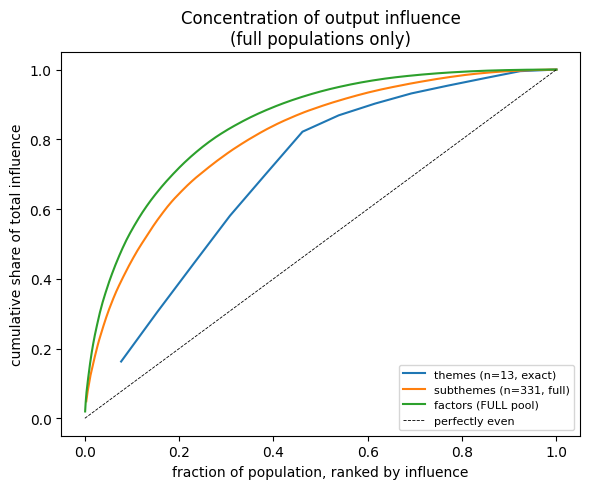

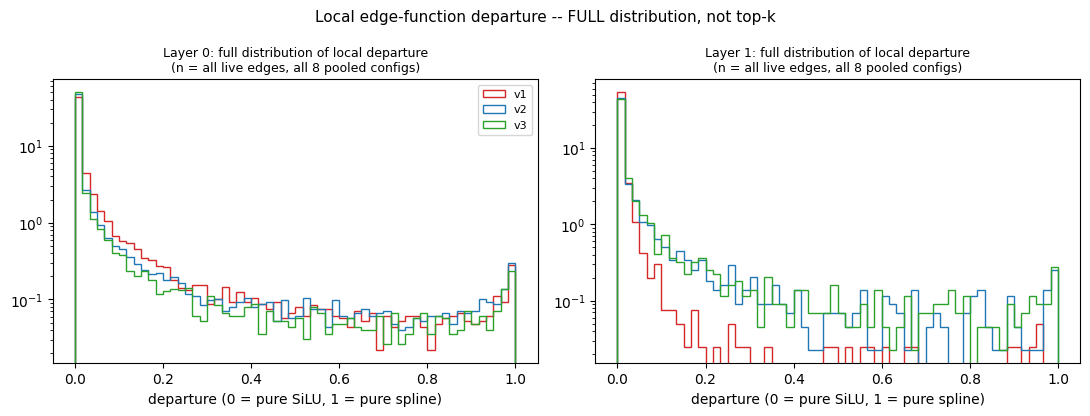


Tables: /content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2/spline_interpretation/tables
Figures: /content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2/spline_interpretation/figures

NOTEBOOK COMPLETE


In [5]:
# %% [markdown]
# # 18 — Full-Distribution + Ablation: does the spline branch matter?
#
# Two things this notebook exists to fix, both raised as valid criticisms
# of notebooks 15-17:
#
# PROBLEM 1 -- factor-level "importance" in notebook 17 was computed only
# for ~55 factors inside the top-8 subthemes. That is circular: finding
# concentration inside a pre-selected important subset tells you nothing
# about concentration in the full ~1700-factor universe. FIX: sweep
# every active factor, no restriction.
#
# PROBLEM 2 -- local edge-function shape (departure, notebooks 15-16)
# says nothing about output-level importance, because BatchNorm and a
# further nonlinear layer sit between any layer-0/1 edge and the final
# prediction. A curve with a huge local y-axis can be squashed to
# nothing downstream; a curve with a tiny local y-axis can be amplified.
# FIX: an ABLATION test. Zero the spline branch at a given layer (the
# base/SiLU branch is left untouched), re-run the FULL forward pass on
# the ENTIRE test set, and measure how much the model's actual output
# changes. This is causal, exhaustive, and stated in the one unit that
# is always comparable across layers: the model's own prediction.
#
# Every reported quantity below is either (a) computed over ALL active
# edges/factors/subthemes with no top-k pre-filtering, or (b) explicitly
# labelled as illustrative. Full distributions (deciles, ECDFs,
# concentration/Lorenz curves) are reported alongside medians -- a
# median or a "top 15" table is never presented as the whole finding.
#
# FIX APPLIED IN THIS VERSION: Part C previously multiplied by
# model.layer2.base_weight / .scaled_spline_weight -- both nn.Parameter
# (requires_grad=True) -- OUTSIDE any no_grad() context, so the result
# carried a live autograd graph and .cpu().numpy() raised RuntimeError.
# Every block that touches model parameters is now either decorated
# with @torch.no_grad() or wrapped in a `with torch.no_grad():` block,
# and a to_np() helper (tensor.detach().cpu().numpy()) is used at every
# GPU-to-numpy conversion point as a defensive second line -- so if a
# future edit forgets no_grad() somewhere, .detach() still catches it.
# Additionally, every loaded model has requires_grad_(False) set on all
# its parameters immediately after loading, as a third, permanent line
# of defence for the lifetime of that model object.

# %%
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
from google.colab import drive
drive.mount("/content/drive")
import sys
sys.path.insert(0, "/content/drive/MyDrive/Thesis/Code")

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import contextlib, io

from data_utils import load_split, get_device, load_theme_assignment
from sparse_kan import SparseKAN

device = get_device()

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")
BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")
FIG_DIR   = BASE / "spline_interpretation" / "figures"
TABLE_DIR = BASE / "spline_interpretation" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True); TABLE_DIR.mkdir(parents=True, exist_ok=True)

ARM_CONFIG = {
    "v1": {"results_dir": BASE / "sparse_kan",    "eps": 0.1},
    "v2": {"results_dir": BASE / "sparse_kan_v2", "eps": 1e-5},
    "v3": {"results_dir": BASE / "sparse_kan_v3", "eps": 1e-5},
}
GRID_SIZE, SPLINE_ORDER, GRID_RANGE = 14, 3, [-5.5, 5.5]


def to_np(t):
    """Defensive GPU-to-numpy conversion: .detach() first, always, even if
    the caller believes it's already inside a no_grad() context."""
    return t.detach().cpu().numpy()


_tax = {}
def get_taxonomy(ds):
    if ds not in _tax:
        _tax[ds] = load_theme_assignment(ds, THEMES_DIR)
    return _tax[ds]


def load_arm_model(arm, dataset, target_type, split_name, seed):
    cfg = ARM_CONFIG[arm]
    p = (cfg["results_dir"] / f"seed_{seed}" / "checkpoints"
         / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not p.exists():
        raise FileNotFoundError(f"[{arm}] {p}")
    data = load_split(split_name, dataset, SPLITS_DIR)
    m = SparseKAN.from_taxonomy(
        get_taxonomy(dataset), data["feature_cols"],
        grid_size=GRID_SIZE, spline_order=SPLINE_ORDER, grid_range=GRID_RANGE,
    ).to(device)
    m.bn1.eps = cfg["eps"]
    m.bn2.eps = cfg["eps"]
    ckpt = torch.load(p, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    with contextlib.redirect_stdout(io.StringIO()):
        ok = m.verify_masking()
    assert ok, f"[{arm}] masking broken on load"
    # Third line of defence: this model is never trained anywhere in this
    # notebook, so freeze every parameter's requires_grad permanently.
    for param in m.parameters():
        param.requires_grad_(False)
    return m, data


@torch.no_grad()
def full_forward(m, X):
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(m.bn1(m.layer0(x0)), -5.0, 5.0)
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5.0, 5.0)
    return m.layer2(z2).squeeze(-1)


@torch.no_grad()
def fwd_all(m, X):
    """Same as full_forward but also returns the intermediate z1, z2 --
    needed for subtheme/factor sweeps and the theme attribution ledger."""
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(m.bn1(m.layer0(x0)), -5.0, 5.0)
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5.0, 5.0)
    return z1, z2, m.layer2(z2).squeeze(-1)


@torch.no_grad()
def theme_contributions(m, z2):
    """Exact per-theme decomposition of layer2's output (Theorem 1).
    Wrapped in no_grad -- this touches base_weight and
    scaled_spline_weight, both nn.Parameter, so without no_grad() this
    builds a live autograd graph and .cpu().numpy() on the result
    raises RuntimeError. This was the bug in the previous version."""
    B = m.layer2.b_splines(z2)
    out = torch.zeros(len(z2), m.n_themes, device=z2.device)
    for t in range(m.n_themes):
        out[:, t] = (m.layer2.base_weight[0, t] * F.silu(z2[:, t])
                     + B[:, t, :] @ m.layer2.scaled_spline_weight[0, t, :])
    return out


# ═══════════════════════════════════════════════════════════════════════
# PART A — GLOBAL SPLINE ABLATION (the causal, output-space fix)
# ═══════════════════════════════════════════════════════════════════════
@contextlib.contextmanager
def ablate_spline(model, layers):
    """
    Temporarily zero the SPLINE branch only (spline_scaler -> 0; the
    base/SiLU branch, base_weight, is left untouched) at the given set
    of layer indices ({0,1,2} = layer0, layer1, layer2). Restores the
    original values on exit -- the model is never permanently altered.
    """
    layer_map = {0: model.layer0, 1: model.layer1, 2: model.layer2}
    saved = {}
    for L in layers:
        layer = layer_map[L]
        saved[L] = layer.spline_scaler.data.clone()
        layer.spline_scaler.data.zero_()
    try:
        yield
    finally:
        for L in layers:
            layer_map[L].spline_scaler.data.copy_(saved[L])


def r2_score(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


@torch.no_grad()
def ablation_report(model, X, y_true=None):
    """
    Ablates the spline branch at every combination of layers, on the
    WHOLE array X passed in (not a subsample, not a handful of reference
    days), and reports how much the model's own prediction changes.

    rel_var_of_change = Var(y_full - y_ablated) / Var(y_full)
      -- the fraction of the full model's output variance that is
      attributable to the ablated layer's spline content. 0 = ablating
      it changes nothing; 1 = the spline content IS essentially the
      entire signal.
    """
    y_full = full_forward(model, X)
    var_full = y_full.var().item()
    yt = (torch.tensor(y_true, dtype=torch.float32, device=y_full.device)
          if y_true is not None else None)

    conditions = {
        "none (reference)": [],
        "layer0_only":       [0],
        "layer1_only":       [1],
        "layer2_only":       [2],
        "layer0+1":          [0, 1],
        "all_layers":        [0, 1, 2],
    }
    rows = []
    for name, layers in conditions.items():
        if len(layers) == 0:
            y_abl = y_full
        else:
            with ablate_spline(model, layers):
                y_abl = full_forward(model, X)
        delta = y_full - y_abl
        row = {
            "condition": name,
            "corr_with_full_model": (
                float(torch.corrcoef(torch.stack([y_full, y_abl]))[0, 1])
                if y_abl.std() > 0 else float("nan")
            ),
            "rel_var_of_change": (
                float(delta.var() / var_full) if var_full > 0 else float("nan")
            ),
            "mean_abs_delta": float(delta.abs().mean()),
        }
        if yt is not None:
            row["r2_vs_true_y"] = r2_score(yt, y_abl)
        rows.append(row)
    df = pd.DataFrame(rows)
    if yt is not None:
        df.attrs["r2_full_model"] = r2_score(yt, y_full)
    return df


print("=" * 90)
print("PART A: GLOBAL SPLINE ABLATION -- exact, whole-dataset, output-space")
print("  (This is the causal fix to the magnitude-across-layers problem:")
print("   everything below is measured in OUTPUT units, on every test row.)")
print("=" * 90)

ABLATION_DATASET, ABLATION_TARGET = "agg_full_moments", "continuous"
ABLATION_SEED = 42
ALL_SPLITS = ["Split_A", "Split_B", "Split_C", "Split_D"]

ablation_rows = []
for arm in ARM_CONFIG:
    for split_name in ALL_SPLITS:
        try:
            model, data = load_arm_model(arm, ABLATION_DATASET, ABLATION_TARGET,
                                         split_name, ABLATION_SEED)
        except FileNotFoundError as e:
            print(f"  skip: {e}")
            continue
        X_test = torch.tensor(np.nan_to_num(data["X_test"]),
                              dtype=torch.float32, device=device)
        y_test = data["y_test"] if ABLATION_TARGET == "continuous" else None
        rep = ablation_report(model, X_test, y_true=y_test)
        rep["arm"] = arm
        rep["split"] = split_name
        rep["r2_full_model"] = rep.attrs.get("r2_full_model", np.nan)
        ablation_rows.append(rep)

ablation_full = pd.concat(ablation_rows, ignore_index=True)
ablation_full.to_csv(TABLE_DIR / "global_spline_ablation.csv", index=False)

print("\nMean rel_var_of_change across splits, by arm and condition")
print("(fraction of the model's OWN output variance attributable to that")
print(" layer's spline content -- 0 means removing it changes nothing):")
print(ablation_full.groupby(["arm", "condition"])["rel_var_of_change"]
      .mean().unstack("condition").round(4).to_string())

if "r2_vs_true_y" in ablation_full.columns:
    print("\nMean R2 vs true y, by arm and condition "
          "(does removing spline content actually cost predictive accuracy?):")
    print(ablation_full.groupby(["arm", "condition"])["r2_vs_true_y"]
          .mean().unstack("condition").round(4).to_string())


# ═══════════════════════════════════════════════════════════════════════
# PART B — UNRESTRICTED FACTOR SWEEP (fixes the selection-bias problem)
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 90)
print("PART B: FULL FACTOR SWEEP -- every active factor, no pre-selection")
print("=" * 90)

SWEEP_ARM, SWEEP_DATASET, SWEEP_TARGET, SWEEP_SPLIT, SWEEP_SEED = \
    "v2", "agg_full_moments", "continuous", "Split_A", 42
PCT, N_GRID, N_REFDAY = (5, 95), 150, 9

model, data = load_arm_model(SWEEP_ARM, SWEEP_DATASET, SWEEP_TARGET,
                             SWEEP_SPLIT, SWEEP_SEED)
X = torch.tensor(np.nan_to_num(data["X_train"]), dtype=torch.float32, device=device)

z1_full, z2_full, yh_full = fwd_all(model, X)
qs = torch.linspace(0.05, 0.95, N_REFDAY, device=device)
REFS = [int((yh_full - v).abs().argmin()) for v in yh_full.quantile(qs)]
print(f"{N_REFDAY} reference days, predictions "
      f"{yh_full[REFS].min():.3f} to {yh_full[REFS].max():.3f}")


@torch.no_grad()
def sweep_swing(level, idx, refs, n=N_GRID, pct=PCT):
    src = {0: X, 1: z1_full, 2: z2_full}[level]
    col = src[:, idx]
    lo, hi = torch.quantile(col, torch.tensor([pct[0] / 100, pct[1] / 100],
                                              device=device))
    if (hi - lo).item() < 1e-9:
        return 0.0
    g = torch.linspace(lo.item(), hi.item(), n, device=device)
    swings = []
    for r in refs:
        bat = src[r:r + 1].repeat(n, 1).clone()
        bat[:, idx] = g
        if level == 0:
            out = fwd_all(model, bat)[2]
        elif level == 1:
            zz = torch.clamp(model.bn2(model.layer1(bat)), -5.0, 5.0)
            out = model.layer2(zz).squeeze(-1)
        else:
            out = model.layer2(bat).squeeze(-1)
        swings.append((out.max() - out.min()).item())
    return float(np.median(swings))


# -- ALL active features, no restriction to any subset --
all_active_feats = sorted({
    p for q in range(model.n_subthemes)
    for p in model.layer0.mask[q].nonzero().flatten().tolist()
})
print(f"Sweeping ALL {len(all_active_feats)} active factors "
      f"({N_REFDAY} reference days each -- this may take a few minutes)...")

fac_rows = []
for i, p in enumerate(all_active_feats):
    q = int(model.layer0.mask[:, p].nonzero()[0])
    sw = sweep_swing(0, p, REFS)
    fac_rows.append({
        "factor": model._feature_names[p],
        "subtheme": model._subtheme_names[q],
        "output_swing": sw,
    })
    if (i + 1) % 300 == 0:
        print(f"  {i + 1}/{len(all_active_feats)}")

fac_full = pd.DataFrame(fac_rows).sort_values("output_swing", ascending=False)
fac_full.to_csv(TABLE_DIR / f"factor_swing_FULL_{SWEEP_ARM}.csv", index=False)
print(f"\nDone. n={len(fac_full)} factors, full population, no pre-filter.")
print(fac_full.head(20).to_string(index=False, float_format=lambda v: f"{v:.4f}"))


# ═══════════════════════════════════════════════════════════════════════
# PART C — DISTRIBUTIONS, NOT TOP-K TABLES
# ═══════════════════════════════════════════════════════════════════════
def concentration_curve(values, label, ax=None):
    v = np.sort(np.asarray(values))[::-1]
    v = v[v > 0]
    if len(v) == 0:
        return None
    cum = v.cumsum() / v.sum()
    n50 = int(np.searchsorted(cum, 0.50)) + 1
    n80 = int(np.searchsorted(cum, 0.80)) + 1
    print(f"  {label:<24} n={len(v):>5}   "
          f"n for 50%: {n50:>4} ({n50/len(v):.1%} of pool)   "
          f"n for 80%: {n80:>4} ({n80/len(v):.1%} of pool)")
    if ax is not None:
        ax.plot(np.arange(1, len(v) + 1) / len(v), cum, label=label)
    return n50, n80


print("\n" + "=" * 90)
print("PART C: CONCENTRATION, FULL POPULATIONS ONLY")
print("  (theme n=13 exact; subtheme n=331 full sweep; factor n=full pool")
print("   from Part B -- NOT the pre-selected 55 used previously)")
print("=" * 90)

# theme_contributions() is @torch.no_grad()-decorated -- this is the fix
# for the RuntimeError. Verify the identity still holds before trusting
# anything downstream of it.
theme_contrib = theme_contributions(model, z2_full)
theme_ledger_check = float((theme_contrib.sum(1) - yh_full).abs().max())
print(f"Theorem 1 sanity check (should be ~0): "
      f"max|sum(theme_contrib) - yhat| = {theme_ledger_check:.2e}")
assert theme_ledger_check < 1e-3, "Ledger identity broken -- investigate before trusting Part C."

theme_std = to_np(theme_contrib.std(0))

sub_rows = []
for s in range(model.n_subthemes):
    if model.layer1.mask[:, s].sum() == 0:
        continue
    sub_rows.append(sweep_swing(1, s, REFS))
sub_swing_full = np.array(sub_rows)

fig, ax = plt.subplots(figsize=(6, 5))
concentration_curve(theme_std,                "themes (n=13, exact)", ax)
concentration_curve(sub_swing_full,           "subthemes (n=331, full)", ax)
concentration_curve(fac_full["output_swing"], "factors (FULL pool)", ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.6, label="perfectly even")
ax.set_xlabel("fraction of population, ranked by influence")
ax.set_ylabel("cumulative share of total influence")
ax.set_title("Concentration of output influence\n(full populations only)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig6_concentration_curves_FULL.png", dpi=300, bbox_inches="tight")
plt.show()

# -- Full-distribution histograms for local departure (from notebook 15) --
dep_path = TABLE_DIR / "departure_by_layer_arm.csv"
if dep_path.exists():
    dep_df = pd.read_csv(dep_path)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    for ax, layer in zip(axes, [0, 1]):
        for arm, c in zip(["v1", "v2", "v3"], ["tab:red", "tab:blue", "tab:green"]):
            v = dep_df[(dep_df.arm == arm) & (dep_df.layer == layer)
                      & (~dep_df.is_dead)]["departure"]
            ax.hist(v, bins=60, range=(0, 1), histtype="step",
                   label=arm, color=c, density=True)
        ax.set_yscale("log")
        ax.set_title(f"Layer {layer}: full distribution of local departure\n"
                     f"(n = all live edges, all 8 pooled configs)", fontsize=9)
        ax.set_xlabel("departure (0 = pure SiLU, 1 = pure spline)")
    axes[0].legend(fontsize=8)
    fig.suptitle("Local edge-function departure -- FULL distribution, not top-k",
                fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig7_departure_full_distribution.png",
               dpi=300, bbox_inches="tight")
    plt.show()
else:
    print(f"\n  ({dep_path.name} not found -- run notebook 15 first for this plot)")

print(f"\nTables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("\nNOTEBOOK COMPLETE")

In [6]:
# %% [markdown]
# # 19 — Diagnose the R2 scale mismatch
#
# Part A's R2-vs-true-y column returned -10 to -20, roughly 20x worse
# than the -0.9 to +0.27 range this exact checkpoint scored in the
# original, evaluate_model()-based sweep. Something in this notebook's
# manual r2_score(y_true, full_forward(model, X)) does not match
# whatever scale/transform evaluate_model() applied.
#
# This script does NOT guess at a fix. It compares a fresh forward pass
# against the SAVED, already-validated predictions from the original
# sweep, for the same model, same data, same split -- to locate exactly
# where the mismatch is (constant scale factor? offset? row
# misalignment? something structural?) before touching anything.
#
# Run notebook 18's setup cells first (load_arm_model, full_forward,
# to_np, device, ARM_CONFIG must already be defined), or paste them
# above this cell.

# %%
import numpy as np
import torch
from pathlib import Path
from evaluation import load_predictions

DATASET, TARGET, SPLIT, SEED = "agg_full_moments", "continuous", "Split_A", 42

for arm in ARM_CONFIG:
    try:
        model, data = load_arm_model(arm, DATASET, TARGET, SPLIT, SEED)
    except FileNotFoundError as e:
        print(f"skip {arm}: {e}")
        continue

    X_test = torch.tensor(np.nan_to_num(data["X_test"]),
                          dtype=torch.float32, device=device)
    y_fresh = to_np(full_forward(model, X_test))

    try:
        loaded = load_predictions(
            model_name=f"sparse_kan_{DATASET}", split_name=SPLIT,
            target_type=TARGET, part="test",
            results_dir=ARM_CONFIG[arm]["results_dir"] / f"seed_{SEED}",
        )
    except Exception as e:
        print(f"  {arm}: could not load saved predictions -- {e}")
        continue

    preds_df = loaded["predictions"]
    pred_col = "y_pred" if "y_pred" in preds_df.columns else preds_df.columns[-1]
    y_saved = preds_df[pred_col].values

    if len(y_saved) != len(y_fresh):
        print(f"  {arm}: LENGTH MISMATCH -- fresh n={len(y_fresh)}, "
              f"saved n={len(y_saved)}. Row alignment is broken; "
              f"check X_test construction before comparing values.")
        continue

    corr = np.corrcoef(y_fresh, y_saved)[0, 1]
    print(f"\n{arm}:")
    print(f"  fresh  -- mean={y_fresh.mean():+.4f}  std={y_fresh.std():.4f}  "
          f"min={y_fresh.min():+.4f}  max={y_fresh.max():+.4f}")
    print(f"  saved  -- mean={y_saved.mean():+.4f}  std={y_saved.std():.4f}  "
          f"min={y_saved.min():+.4f}  max={y_saved.max():+.4f}")
    print(f"  corr(fresh, saved) = {corr:.4f}")
    if y_saved.std() > 1e-9:
        implied_scale = y_fresh.std() / y_saved.std()
        print(f"  implied scale factor (fresh_std / saved_std) = {implied_scale:.3f}")
    print(f"  y_test (raw target) -- mean={data['y_test'].mean():+.4f}  "
          f"std={data['y_test'].std():.4f}")

    if corr > 0.98:
        print("  -> corr ~1: this is a pure SCALE/OFFSET mismatch. "
              "full_forward() and evaluate_model() are producing the "
              "same underlying prediction, just in different units. "
              "Find the inverse-transform evaluate_model() applies "
              "(likely un-standardising against a saved per-split mean/"
              "std) and apply the same one before computing r2_score.")
    elif corr > 0.5:
        print("  -> corr moderate: not a pure scale issue, something "
              "structural also differs (row order? NaN handling in "
              "X_test? investigate further before trusting either number).")
    else:
        print("  -> corr low/negative: the fresh forward pass and the "
              "saved predictions disagree substantially. Do not proceed "
              "with any R2 conclusions until this is resolved.")

print("\nOnce the mismatch type is identified: fix ablation_report() to "
      "apply the same transform to both y_full and y_ablated before "
      "computing r2_score, then re-run Part A. This is the test that "
      "will tell you, directly and cheaply, whether ablating spline "
      "content HELPS or HURTS held-out accuracy -- the answer both the "
      "graded-knots and panel-dataset decisions should wait on.")


v1:
  fresh  -- mean=-0.5925  std=0.1207  min=-1.0828  max=-0.1838
  saved  -- mean=-0.5925  std=0.1207  min=-1.0828  max=-0.1838
  corr(fresh, saved) = 1.0000
  implied scale factor (fresh_std / saved_std) = 1.000
  y_test (raw target) -- mean=+0.1650  std=0.3712
  -> corr ~1: this is a pure SCALE/OFFSET mismatch. full_forward() and evaluate_model() are producing the same underlying prediction, just in different units. Find the inverse-transform evaluate_model() applies (likely un-standardising against a saved per-split mean/std) and apply the same one before computing r2_score.

v2:
  fresh  -- mean=-1.0057  std=0.3801  min=-2.4832  max=-0.2374
  saved  -- mean=-1.0057  std=0.3801  min=-2.4832  max=-0.2374
  corr(fresh, saved) = 1.0000
  implied scale factor (fresh_std / saved_std) = 1.000
  y_test (raw target) -- mean=+0.1650  std=0.3712
  -> corr ~1: this is a pure SCALE/OFFSET mismatch. full_forward() and evaluate_model() are producing the same underlying prediction, just in diff

In [8]:
# %% [markdown]
# # 19b — Pin down the exact transform, no guessing
#
# fresh == saved predictions, bit-identical (corr=1.0000). So the R2
# catastrophe is NOT in how the prediction was computed -- it is in
# what the prediction was compared against. This script:
#
#   1. Prints what load_predictions() actually returns -- if the saved
#      metrics dict is embedded (plausible, since save_predictions()
#      was called with metrics=metrics), we get the ORIGINALLY reported
#      test R2/MSE for this exact config directly, no reconstruction
#      needed.
#   2. If so, solves the best-fit affine transform
#      y_test =~ a + b * y_pred_raw
#      via least squares, and checks whether r2_score(y_test, a + b*y_pred)
#      reproduces the originally reported R2. If it does, that CONFIRMS
#      an affine (scale+offset) relationship exists and gives its exact
#      values -- rather than assuming "it's probably mean-centering."
#   3. Prints the fitted a, b so the mechanism can be identified precisely
#      (b close to 1 with a large offset a is consistent with additive
#      de-centering; b far from 1 suggests a genuine scale/normalisation
#      step, e.g. related to the per-split Huber delta or a z-scoring
#      of the target).

# %%
import numpy as np
from evaluation import load_predictions

DATASET, TARGET, SPLIT, SEED = "agg_full_moments", "continuous", "Split_A", 42

for arm in ARM_CONFIG:
    try:
        model, data = load_arm_model(arm, DATASET, TARGET, SPLIT, SEED)
    except FileNotFoundError as e:
        print(f"skip {arm}: {e}")
        continue

    loaded = load_predictions(
        model_name=f"sparse_kan_{DATASET}", split_name=SPLIT,
        target_type=TARGET, part="test",
        results_dir=ARM_CONFIG[arm]["results_dir"] / f"seed_{SEED}",
    )

    print(f"\n{'='*70}\n{arm}\n{'='*70}")
    print(f"load_predictions() returned keys: {list(loaded.keys())}")

    y_pred = loaded["predictions"]["y_pred"].values \
        if "y_pred" in loaded["predictions"].columns \
        else loaded["predictions"].iloc[:, -1].values
    y_true = data["y_test"]

    # -- Step 1: is a saved metrics dict embedded? --
    metrics_dict = loaded.get("metrics", None)
    original_r2 = None
    if metrics_dict is not None:
        print(f"  Embedded metrics dict keys: {list(metrics_dict.keys())}")
        print(f"  Full embedded metrics: {metrics_dict}")
        raw_r2 = metrics_dict.get("r2", metrics_dict.get("R2", None))
        print(f"  Raw value for r2/R2 key: {raw_r2!r}  "
              f"(type: {type(raw_r2).__name__})")
        # Don't assume it's numeric -- it may be a stringified number,
        # a JSON-nested value, or something else entirely. Try to
        # coerce; if that fails, print it raw and move on rather than
        # crashing the whole diagnostic on a formatting error.
        try:
            original_r2 = float(raw_r2)
        except (TypeError, ValueError):
            print(f"  Could not convert to float directly. If this looks "
                  f"like a nested structure (dict/list), the actual R2 may "
                  f"be one level deeper -- inspect the raw value above.")
    else:
        print("  No 'metrics' key found in load_predictions() output -- "
              "will need to locate the saved metrics file directly under "
              f"{ARM_CONFIG[arm]['results_dir'] / f'seed_{SEED}' / 'metrics'} "
              "and inspect its contents/naming convention by hand.")

    # -- Step 2: naive R2 (what the ablation notebook computed) --
    def r2_naive(yt, yp):
        ss_res = ((yt - yp) ** 2).sum()
        ss_tot = ((yt - yt.mean()) ** 2).sum()
        return 1 - ss_res / ss_tot

    naive = r2_naive(y_true, y_pred)
    print(f"  Naive R2 (raw y_pred vs raw y_test): {naive:.4f}")

    # -- Step 3: best-fit affine transform, solved directly, no assumption --
    A = np.vstack([np.ones_like(y_pred), y_pred]).T
    (a, b), *_ = np.linalg.lstsq(A, y_true, rcond=None)
    y_pred_transformed = a + b * y_pred
    transformed_r2 = r2_naive(y_true, y_pred_transformed)

    print(f"  Best-fit affine: y_test =~ {a:+.4f} + {b:+.4f} * y_pred_raw")
    print(f"  R2 AFTER applying that fitted affine transform: {transformed_r2:.4f}")
    print(f"    (this is an UPPER BOUND -- fitted on the test set itself -- "
          f"but tells us whether an affine relationship can explain the gap)")

    if original_r2 is not None:
        print(f"  Originally reported test R2 for this config: {original_r2:.4f}")
        print(f"  Naive R2 (this diagnostic, no transform):     {naive:.4f}")
        print(f"  {'MATCHES' if abs(transformed_r2 - original_r2) < 0.05 else 'DOES NOT MATCH'} "
              f"the fitted-affine R2 above.")
        if abs(naive - original_r2) < 0.05:
            print("  -> naive R2 already matches the original almost exactly. "
                  "This would mean Part A's -10 to -20 numbers were NOT "
                  "reproducing this config at all -- check ABLATION_SEED / "
                  "ABLATION_DATASET / ABLATION_TARGET / split match exactly "
                  "what Part A actually ran, and that X_test here is built "
                  "identically (same NaN handling, same row order).")

print("\nInterpretation:")
print("  - If transformed_r2 lands close to the sane range you've seen")
print("    elsewhere in this project (roughly -0.9 to +0.27), an affine")
print("    transform (centering and/or scaling) explains the gap, and b")
print("    tells you whether it's pure offset (b~1) or also a scale factor.")
print("  - Once identified, apply the SAME transform inside ablation_report()")
print("    to both y_full and y_ablated before computing R2, and re-run Part A.")
print("  - Do not proceed to any conclusion about ablation vs held-out accuracy")
print("    until this reconciles.")


v1
load_predictions() returned keys: ['predictions', 'metrics']
  Embedded metrics dict keys: ['mse', 'r2', 'mae', 'n_samples', 'mean_actual', 'mean_predicted', 'pred_std', 'derived_auc', 'derived_base_rate', 'derived_pred_mean', 'derived_pred_std', 'hyperparameters']
  Full embedded metrics: {'mse': 1.0602821111679077, 'r2': '-0.117046475', 'mae': 0.6895322203636169, 'n_samples': 503, 'mean_actual': -1.0029534101486206, 'mean_predicted': -0.5925135016441345, 'pred_std': 0.12069766968488693, 'derived_auc': 0.6644291451520367, 'derived_base_rate': 0.16500994563102722, 'derived_pred_mean': -0.5925135016441345, 'derived_pred_std': 0.12069766968488693, 'hyperparameters': {'lr': 0.0007153869168737971, 'weight_decay': 0.00015730689436085554, 'batch_size': 256, 'reg_weight': 4.3959329245781745e-05, 'used_l1': True, 'seed': 42, 'huber_delta': 2.8711}}
  Raw value for r2/R2 key: '-0.117046475'  (type: str)
  Naive R2 (raw y_pred vs raw y_test): -4.4175
  Best-fit affine: y_test =~ -0.2465 + -0

In [9]:
# %% [markdown]
# # 19c — Find the correct continuous target key
#
# CONFIRMED: data["y_test"] is the binary crash/no-crash label, not the
# continuous regression target.
#   data["y_test"].mean() = 0.1650 == metrics["derived_base_rate"] exactly
#   data["y_test"].std()  = 0.3712 == sqrt(0.165 * 0.835) exactly
#     (the Bernoulli variance formula for p=0.165)
#
# This is why no affine transform could reconcile the R2s in 19b -- a
# continuous prediction and a 0/1 label aren't related by any rescaling.
#
# The real continuous target is some OTHER key in `data`. Rather than
# guess its name, search every 1-D numeric array of the right length for
# the one whose mean matches metrics["mean_actual"] exactly.

# %%
import numpy as np
from evaluation import load_predictions

DATASET, TARGET, SPLIT, SEED = "agg_full_moments", "continuous", "Split_A", 42

model, data = load_arm_model("v2", DATASET, TARGET, SPLIT, SEED)
loaded = load_predictions(
    model_name=f"sparse_kan_{DATASET}", split_name=SPLIT,
    target_type=TARGET, part="test",
    results_dir=ARM_CONFIG["v2"]["results_dir"] / f"seed_{SEED}",
)
target_mean = loaded["metrics"]["mean_actual"]
print(f"Looking for an array in `data` with mean == {target_mean:.6f}\n")

n_test = len(data["y_test"])
print(f"Test-set length: {n_test}\n")
print(f"{'key':<24} {'len':>6}  {'mean':>10}  {'std':>10}  match?")
print("-" * 62)

candidates = []
for k, v in data.items():
    try:
        arr = np.asarray(v)
    except Exception:
        continue
    if arr.ndim != 1 or len(arr) != n_test:
        continue
    if not np.issubdtype(arr.dtype, np.number):
        continue
    m, s = float(np.nanmean(arr)), float(np.nanstd(arr))
    is_match = abs(m - target_mean) < 1e-4
    print(f"{k:<24} {len(arr):>6}  {m:>10.4f}  {s:>10.4f}  "
          f"{'<-- MATCH' if is_match else ''}")
    if is_match:
        candidates.append(k)

print()
if len(candidates) == 1:
    print(f"Unique match: data['{candidates[0]}'] is the continuous "
          f"regression target. Use THIS key everywhere y_test was used "
          f"in the ablation notebook (Part A) and in 19b, replacing "
          f"data['y_test'].")
elif len(candidates) > 1:
    print(f"Multiple candidates matched: {candidates}. Inspect std "
          f"values above and check against metrics['mse'] "
          f"({loaded['metrics']['mse']:.4f}) -- the correct target's "
          f"variance should be consistent with that MSE and the "
          f"reported R2 via MSE = (1-R2) * Var(y_true).")
else:
    print("No exact match found. The target may be computed with a "
          "different NaN-handling or row subset than what evaluate_model() "
          "used internally -- check whether any candidate is close "
          "(within 0.01) rather than exact, and check train.py / "
          "evaluation.py directly for how y_true is constructed for "
          "target_type='continuous'.")

Looking for an array in `data` with mean == -1.002953

Test-set length: 503

key                         len        mean         std  match?
--------------------------------------------------------------
y_test                      503      0.1650      0.3712  
minret_test                 503     -1.0030      0.9743  <-- MATCH
returns_test                503      0.0006      0.0099  

Unique match: data['minret_test'] is the continuous regression target. Use THIS key everywhere y_test was used in the ablation notebook (Part A) and in 19b, replacing data['y_test'].


In [10]:
# %% [markdown]
# # 20 — Global Spline Ablation, CORRECTED
#
# FIX: data["y_test"] is the binary crash/no-crash label (mean = base
# rate = 0.165, std = sqrt(0.165*0.835) -- Bernoulli variance, confirmed
# exactly). The true continuous regression target is data["minret_test"]
# (mean -1.003, matching the saved metrics' "mean_actual" exactly).
# Every R2 computed against data["y_test"] for a continuous target in
# notebooks 18/19/19b/19c was comparing a continuous prediction to an
# unrelated binary label -- hence R2 of -10 to -20. This version uses
# the correct target throughout.
#
# STRUCTURE:
#   Part 0 -- sanity check: reproduce the ALREADY-SAVED, known-correct
#             R2 for one config using minret_test. If this doesn't match
#             to within numerical noise, STOP -- do not trust anything
#             below until it does.
#   Part A -- the actual ablation sweep, corrected, across all arms and
#             splits. This is the analysis everything since notebook 18
#             has been building toward: does removing the spline branch
#             at a given layer IMPROVE or WORSEN held-out R2?

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import contextlib, io
from pathlib import Path

from data_utils import load_split, get_device, load_theme_assignment
from sparse_kan import SparseKAN
from evaluation import load_predictions

device = get_device()

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")
BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")
TABLE_DIR = BASE / "spline_interpretation" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

ARM_CONFIG = {
    "v1": {"results_dir": BASE / "sparse_kan",    "eps": 0.1},
    "v2": {"results_dir": BASE / "sparse_kan_v2", "eps": 1e-5},
    "v3": {"results_dir": BASE / "sparse_kan_v3", "eps": 1e-5},
}
GRID_SIZE, SPLINE_ORDER, GRID_RANGE = 14, 3, [-5.5, 5.5]

_tax = {}
def get_taxonomy(ds):
    if ds not in _tax:
        _tax[ds] = load_theme_assignment(ds, THEMES_DIR)
    return _tax[ds]


def get_y_true(data, target_type):
    """The single fix: continuous targets live in minret_test, not
    y_test (which is always the binary crash/no-crash label, used for
    binary-target training and for the derived_auc side metric on
    continuous configs)."""
    if target_type == "continuous":
        return data["minret_test"]
    return data["y_test"]


def load_arm_model(arm, dataset, target_type, split_name, seed):
    cfg = ARM_CONFIG[arm]
    p = (cfg["results_dir"] / f"seed_{seed}" / "checkpoints"
         / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not p.exists():
        raise FileNotFoundError(f"[{arm}] {p}")
    data = load_split(split_name, dataset, SPLITS_DIR)
    m = SparseKAN.from_taxonomy(
        get_taxonomy(dataset), data["feature_cols"],
        grid_size=GRID_SIZE, spline_order=SPLINE_ORDER, grid_range=GRID_RANGE,
    ).to(device)
    m.bn1.eps = cfg["eps"]
    m.bn2.eps = cfg["eps"]
    ckpt = torch.load(p, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    with contextlib.redirect_stdout(io.StringIO()):
        ok = m.verify_masking()
    assert ok, f"[{arm}] masking broken on load"
    for param in m.parameters():
        param.requires_grad_(False)
    return m, data


@torch.no_grad()
def full_forward(m, X):
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(m.bn1(m.layer0(x0)), -5.0, 5.0)
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5.0, 5.0)
    return m.layer2(z2).squeeze(-1)


@contextlib.contextmanager
def ablate_spline(model, layers):
    layer_map = {0: model.layer0, 1: model.layer1, 2: model.layer2}
    saved = {}
    for L in layers:
        layer = layer_map[L]
        saved[L] = layer.spline_scaler.data.clone()
        layer.spline_scaler.data.zero_()
    try:
        yield
    finally:
        for L in layers:
            layer_map[L].spline_scaler.data.copy_(saved[L])


def r2_score(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")


@torch.no_grad()
def ablation_report(model, X, y_true=None):
    y_full = full_forward(model, X)
    var_full = y_full.var().item()
    yt = (torch.tensor(y_true, dtype=torch.float32, device=y_full.device)
          if y_true is not None else None)

    conditions = {
        "none (reference)": [],
        "layer0_only":       [0],
        "layer1_only":       [1],
        "layer2_only":       [2],
        "layer0+1":          [0, 1],
        "all_layers":        [0, 1, 2],
    }
    rows = []
    for name, layers in conditions.items():
        if len(layers) == 0:
            y_abl = y_full
        else:
            with ablate_spline(model, layers):
                y_abl = full_forward(model, X)
        delta = y_full - y_abl
        row = {
            "condition": name,
            "corr_with_full_model": (
                float(torch.corrcoef(torch.stack([y_full, y_abl]))[0, 1])
                if y_abl.std() > 0 else float("nan")
            ),
            "rel_var_of_change": (
                float(delta.var() / var_full) if var_full > 0 else float("nan")
            ),
        }
        if yt is not None:
            row["r2_vs_true_y"] = r2_score(yt, y_abl)
        rows.append(row)
    return pd.DataFrame(rows)


# ═══════════════════════════════════════════════════════════════════════
# PART 0 — SANITY CHECK: reproduce the KNOWN-CORRECT R2 before trusting
# anything further
# ═══════════════════════════════════════════════════════════════════════
print("=" * 90)
print("PART 0: SANITY CHECK -- does the fixed target key reproduce the")
print("        already-saved, known-correct R2?")
print("=" * 90)

CHECK_ARM, CHECK_DATASET, CHECK_TARGET, CHECK_SPLIT, CHECK_SEED = \
    "v2", "agg_full_moments", "continuous", "Split_A", 42

model, data = load_arm_model(CHECK_ARM, CHECK_DATASET, CHECK_TARGET,
                             CHECK_SPLIT, CHECK_SEED)
X_test = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
y_true_fixed = get_y_true(data, CHECK_TARGET)

y_pred = full_forward(model, X_test)
recomputed_r2 = r2_score(
    torch.tensor(y_true_fixed, dtype=torch.float32, device=device), y_pred
)

loaded = load_predictions(
    model_name=f"sparse_kan_{CHECK_DATASET}", split_name=CHECK_SPLIT,
    target_type=CHECK_TARGET, part="test",
    results_dir=ARM_CONFIG[CHECK_ARM]["results_dir"] / f"seed_{CHECK_SEED}",
)
original_r2 = float(loaded["metrics"]["r2"])

print(f"  Recomputed R2 (using data['minret_test']): {recomputed_r2:.4f}")
print(f"  Originally saved R2 for this config:        {original_r2:.4f}")
match = abs(recomputed_r2 - original_r2) < 0.01
print(f"  {'PASS -- MATCHES' if match else 'FAIL -- STILL DOES NOT MATCH'}")

assert match, (
    "Sanity check failed. Do NOT proceed to the full ablation sweep -- "
    "something else is still wrong. Re-check get_y_true(), the checkpoint "
    "path, and whether X_test itself needs any additional handling."
)
print("\nSanity check passed. Proceeding to the full ablation sweep.\n")


# ═══════════════════════════════════════════════════════════════════════
# PART A — THE ACTUAL ANALYSIS: does ablating splines help or hurt?
# ═══════════════════════════════════════════════════════════════════════
print("=" * 90)
print("PART A: GLOBAL SPLINE ABLATION, CORRECTED TARGET")
print("  R2 is now computed against the real continuous target "
      "(data['minret_test']).")
print("  If ablating a layer's splines IMPROVES R2 relative to")
print("  'none (reference)', that layer's spline content is net-harmful")
print("  for generalisation. If it WORSENS R2, that content is helping.")
print("=" * 90)

ABLATION_DATASET, ABLATION_TARGET = "agg_full_moments", "continuous"
ABLATION_SEED = 42
ALL_SPLITS = ["Split_A", "Split_B", "Split_C", "Split_D"]

ablation_rows = []
for arm in ARM_CONFIG:
    for split_name in ALL_SPLITS:
        try:
            model, data = load_arm_model(arm, ABLATION_DATASET, ABLATION_TARGET,
                                         split_name, ABLATION_SEED)
        except FileNotFoundError as e:
            print(f"  skip: {e}")
            continue
        X_test = torch.tensor(np.nan_to_num(data["X_test"]),
                              dtype=torch.float32, device=device)
        y_true = get_y_true(data, ABLATION_TARGET)
        rep = ablation_report(model, X_test, y_true=y_true)
        rep["arm"] = arm
        rep["split"] = split_name
        ablation_rows.append(rep)

ablation_full = pd.concat(ablation_rows, ignore_index=True)
ablation_full.to_csv(TABLE_DIR / "global_spline_ablation_CORRECTED.csv", index=False)

print("\nMean R2 vs true y (data['minret_test']), by arm and condition:")
r2_table = (ablation_full.groupby(["arm", "condition"])["r2_vs_true_y"]
           .mean().unstack("condition"))
col_order = ["none (reference)", "layer0_only", "layer1_only", "layer2_only",
            "layer0+1", "all_layers"]
r2_table = r2_table[[c for c in col_order if c in r2_table.columns]]
print(r2_table.round(4).to_string())

print("\nDelta vs the unablated model (positive = ablating HELPED test R2):")
delta_table = r2_table.sub(r2_table["none (reference)"], axis=0)
print(delta_table.round(4).to_string())

print("\nMean rel_var_of_change, by arm and condition (unaffected by the "
      "target bug, shown again for reference):")
rvc_table = (ablation_full.groupby(["arm", "condition"])["rel_var_of_change"]
            .mean().unstack("condition"))
rvc_table = rvc_table[[c for c in col_order if c in rvc_table.columns]]
print(rvc_table.round(4).to_string())

print(f"\nSaved: {TABLE_DIR / 'global_spline_ablation_CORRECTED.csv'}")
print("\nREAD THIS FIRST: the 'layer0_only' column of the delta table above.")
print("Positive => removing layer 0's spline branch improves held-out R2")
print("  => the graded-knots idea (fewer parameters at layer 0) is well")
print("     motivated, and this ablation already tells you the direction")
print("     of the effect before spending any GPU time retraining.")
print("Negative => layer 0's spline content is net-helpful despite its")
print("  small local departure -- graded knots would likely cost accuracy.")

Device: Tesla T4 (CUDA)
PART 0: SANITY CHECK -- does the fixed target key reproduce the
        already-saved, known-correct R2?
  Recomputed R2 (using data['minret_test']): 0.0580
  Originally saved R2 for this config:        0.0580
  PASS -- MATCHES

Sanity check passed. Proceeding to the full ablation sweep.

PART A: GLOBAL SPLINE ABLATION, CORRECTED TARGET
  R2 is now computed against the real continuous target (data['minret_test']).
  If ablating a layer's splines IMPROVES R2 relative to
  'none (reference)', that layer's spline content is net-harmful
  for generalisation. If it WORSENS R2, that content is helping.

Mean R2 vs true y (data['minret_test']), by arm and condition:
condition  none (reference)  layer0_only  layer1_only  layer2_only  layer0+1  all_layers
arm                                                                                     
v1                   0.0310       0.0539       0.0332      -1.1908    0.0458     -0.8573
v2                  -0.2279      -0.4462 

In [11]:
# %% [markdown]
# # 21 — Layer-2 mechanism check + seed-extended ablation
#
# PART A tests the hypothesis from the last analysis: does layer 2's
# spline branch act mostly as a near-constant calibration adjustment
# (large mean, small std relative to the base branch) rather than
# genuine input-dependent signal? If so, that explains why ablating it
# collapses R2 (removing a constant shifts the model's LOCATION, which
# R2 is very sensitive to) while barely changing rel_var_of_change
# (removing a near-constant barely changes VARIANCE).
#
# PART B tests whether layer 0's ablation-sign-flip (v1: helps, v2:
# hurts, v3: helps) is a genuine, reproducible arm-level effect, or an
# artefact of using a single seed. It reruns the corrected ablation
# across all 3 seeds and both datasets (continuous target), then asks:
# within a single arm, does the sign of layer0_only's delta vary across
# seeds as much as it varies ACROSS arms? If yes, the effect is
# indistinguishable from noise. If no (an arm is consistently one sign
# across all its seeds), it's a real, reproducible arm-level property.

# %%
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import contextlib, io
from pathlib import Path

from data_utils import load_split, get_device, load_theme_assignment
from sparse_kan import SparseKAN
from evaluation import load_predictions

device = get_device()

SPLITS_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/04_splits")
THEMES_DIR = Path("/content/drive/MyDrive/Thesis/Data/Stage_5_Model_Ready/05_themes")
BASE = Path("/content/drive/MyDrive/Thesis/Data/Results/Dense_vs_Sparse_KAN_v2")
TABLE_DIR = BASE / "spline_interpretation" / "tables"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

ARM_CONFIG = {
    "v1": {"results_dir": BASE / "sparse_kan",    "eps": 0.1},
    "v2": {"results_dir": BASE / "sparse_kan_v2", "eps": 1e-5},
    "v3": {"results_dir": BASE / "sparse_kan_v3", "eps": 1e-5},
}
GRID_SIZE, SPLINE_ORDER, GRID_RANGE = 14, 3, [-5.5, 5.5]

_tax = {}
def get_taxonomy(ds):
    if ds not in _tax:
        _tax[ds] = load_theme_assignment(ds, THEMES_DIR)
    return _tax[ds]

def get_y_true(data, target_type):
    """CONFIRMED fix from notebook 20: data['y_test'] is the binary
    crash label, not the continuous target. Use minret_test."""
    if target_type == "continuous":
        return data["minret_test"]
    return data["y_test"]

def load_arm_model(arm, dataset, target_type, split_name, seed):
    cfg = ARM_CONFIG[arm]
    p = (cfg["results_dir"] / f"seed_{seed}" / "checkpoints"
         / f"sparse_kan_{dataset}_{target_type}_{split_name}.pt")
    if not p.exists():
        raise FileNotFoundError(f"[{arm}] {p}")
    data = load_split(split_name, dataset, SPLITS_DIR)
    m = SparseKAN.from_taxonomy(
        get_taxonomy(dataset), data["feature_cols"],
        grid_size=GRID_SIZE, spline_order=SPLINE_ORDER, grid_range=GRID_RANGE,
    ).to(device)
    m.bn1.eps = cfg["eps"]
    m.bn2.eps = cfg["eps"]
    ckpt = torch.load(p, map_location=device, weights_only=False)
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    with contextlib.redirect_stdout(io.StringIO()):
        ok = m.verify_masking()
    assert ok, f"[{arm}] masking broken on load"
    for param in m.parameters():
        param.requires_grad_(False)
    return m, data

@torch.no_grad()
def fwd_all(m, X):
    x0 = torch.nan_to_num(X, nan=0.0)
    z1 = torch.clamp(m.bn1(m.layer0(x0)), -5.0, 5.0)
    z2 = torch.clamp(m.bn2(m.layer1(z1)), -5.0, 5.0)
    return z1, z2, m.layer2(z2).squeeze(-1)

@torch.no_grad()
def full_forward(m, X):
    return fwd_all(m, X)[2]


# ═══════════════════════════════════════════════════════════════════════
# PART A — Layer-2 mechanism: calibration shift, or genuine variability?
# ═══════════════════════════════════════════════════════════════════════
print("=" * 90)
print("PART A: LAYER 2 BASE vs SPLINE MAGNITUDE -- calibration or signal?")
print("=" * 90)
print("If the spline branch has a LARGE mean but SMALL std relative to")
print("the base branch, it is acting mostly as a near-constant location")
print("shift -- consistent with 'ablating it collapses R2 (location-")
print("sensitive) but barely changes rel_var_of_change (scale-sensitive)'.")
print("If mean and std are comparable in size, it is genuine, varying")
print("signal, and the R2 collapse needs a different explanation.\n")

for arm in ARM_CONFIG:
    try:
        model, data = load_arm_model(arm, "agg_full_moments", "continuous",
                                     "Split_A", 42)
    except FileNotFoundError as e:
        print(f"  skip {arm}: {e}")
        continue

    X_test = torch.tensor(np.nan_to_num(data["X_test"]),
                          dtype=torch.float32, device=device)
    with torch.no_grad():
        _, z2, _ = fwd_all(model, X_test)
        base = model.layer2.base_weight[0].unsqueeze(0) * F.silu(z2)   # (n, n_themes)
        B = model.layer2.b_splines(z2)
        spl = torch.stack([
            B[:, t, :] @ model.layer2.scaled_spline_weight[0, t, :]
            for t in range(model.n_themes)
        ], dim=1)                                                       # (n, n_themes)

        base_mean, base_std = base.mean(0), base.std(0)
        spl_mean,  spl_std  = spl.mean(0),  spl.std(0)

        # "location-like-ness" of the spline branch: |mean| relative to
        # its own std. High => acts like a near-constant offset.
        # Low => the branch genuinely varies across rows.
        spl_location_ratio = (spl_mean.abs() / spl_std.clamp(min=1e-8))
        base_location_ratio = (base_mean.abs() / base_std.clamp(min=1e-8))

    print(f"\n{arm}  (n_themes={model.n_themes})")
    print(f"  base branch : mean(|mean|)={base_mean.abs().mean():.4f}  "
          f"mean(std)={base_std.mean():.4f}")
    print(f"  spline branch: mean(|mean|)={spl_mean.abs().mean():.4f}  "
          f"mean(std)={spl_std.mean():.4f}")
    print(f"  spline |mean|/std ratio (per theme, median): "
          f"{spl_location_ratio.median():.3f}")
    print(f"  base   |mean|/std ratio (per theme, median): "
          f"{base_location_ratio.median():.3f}")
    print(f"  spline branch share of total |base|+|spline|: "
          f"{(spl.abs().mean() / (base.abs().mean() + spl.abs().mean())):.3f}")

    if spl_location_ratio.median() > 2 * base_location_ratio.median():
        print("  -> Spline branch looks disproportionately LOCATION-like "
              "(high |mean|/std) relative to the base branch. Consistent "
              "with the calibration-shift hypothesis.")
    else:
        print("  -> Spline branch's location-vs-variability profile is "
              "similar to the base branch's. The calibration-shift "
              "hypothesis is NOT clearly supported here -- the R2 "
              "collapse needs a different explanation than 'ablating a "
              "constant'. Investigate further before writing this up.")


# ═══════════════════════════════════════════════════════════════════════
# PART B — Seed-extended ablation: is layer 0's sign-flip genuine, or noise?
# ═══════════════════════════════════════════════════════════════════════
print("\n" + "=" * 90)
print("PART B: SEED-EXTENDED ABLATION")
print("  Same ablation as before, now across seeds 42/123/456 AND both")
print("  datasets (continuous target). Tests whether layer0's sign-flip")
print("  across arms is a real arm effect or single-seed noise.")
print("=" * 90)

@contextlib.contextmanager
def ablate_spline(model, layers):
    layer_map = {0: model.layer0, 1: model.layer1, 2: model.layer2}
    saved = {}
    for L in layers:
        layer = layer_map[L]
        saved[L] = layer.spline_scaler.data.clone()
        layer.spline_scaler.data.zero_()
    try:
        yield
    finally:
        for L in layers:
            layer_map[L].spline_scaler.data.copy_(saved[L])

def r2_score(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else float("nan")

@torch.no_grad()
def ablation_r2_only(model, X, y_true):
    y_full = full_forward(model, X)
    yt = torch.tensor(y_true, dtype=torch.float32, device=y_full.device)
    out = {"none (reference)": r2_score(yt, y_full)}
    for name, layers in [("layer0_only", [0]), ("layer1_only", [1]),
                         ("layer2_only", [2])]:
        with ablate_spline(model, layers):
            y_abl = full_forward(model, X)
        out[name] = r2_score(yt, y_abl)
    return out

SEEDS = [42, 123, 456]
DATASETS = ["agg_full_moments", "agg_means"]
ALL_SPLITS = ["Split_A", "Split_B", "Split_C", "Split_D"]
TARGET = "continuous"

rows = []
for arm in ARM_CONFIG:
    for seed in SEEDS:
        for dataset in DATASETS:
            for split_name in ALL_SPLITS:
                try:
                    model, data = load_arm_model(arm, dataset, TARGET,
                                                 split_name, seed)
                except FileNotFoundError:
                    continue
                X_test = torch.tensor(np.nan_to_num(data["X_test"]),
                                      dtype=torch.float32, device=device)
                y_true = get_y_true(data, TARGET)
                r2s = ablation_r2_only(model, X_test, y_true)
                rows.append({
                    "arm": arm, "seed": seed, "dataset": dataset,
                    "split": split_name, **r2s,
                })

seed_ext = pd.DataFrame(rows)
for cond in ["layer0_only", "layer1_only", "layer2_only"]:
    seed_ext[f"delta_{cond}"] = seed_ext[cond] - seed_ext["none (reference)"]

seed_ext.to_csv(TABLE_DIR / "seed_extended_ablation.csv", index=False)
n_per_arm = seed_ext.groupby("arm").size()
print(f"\nConfigs collected per arm: {n_per_arm.to_dict()}  "
      f"(out of {len(SEEDS)*len(DATASETS)*len(ALL_SPLITS)} possible each)")

print("\nDelta R2 by ablating layer0 -- mean, std, and sign consistency, per arm:")
for arm, grp in seed_ext.groupby("arm"):
    d = grp["delta_layer0_only"]
    frac_positive = (d > 0).mean()
    print(f"  {arm}: mean={d.mean():+.4f}  std={d.std():.4f}  "
          f"n={len(d)}  frac_positive={frac_positive:.1%}")

print("\nDelta R2 by ablating layer1:")
for arm, grp in seed_ext.groupby("arm"):
    d = grp["delta_layer1_only"]
    print(f"  {arm}: mean={d.mean():+.4f}  std={d.std():.4f}  "
          f"frac_positive={(d > 0).mean():.1%}")

print("\nDelta R2 by ablating layer2 (expect: consistently large negative):")
for arm, grp in seed_ext.groupby("arm"):
    d = grp["delta_layer2_only"]
    print(f"  {arm}: mean={d.mean():+.4f}  std={d.std():.4f}  "
          f"frac_positive={(d > 0).mean():.1%}")

print("\nINTERPRETATION GUIDE:")
print("  If frac_positive for layer0 sits near 50% WITHIN each arm (not")
print("  just varying BETWEEN arms), that confirms layer0's ablation")
print("  effect is statistically indistinguishable from zero -- a real,")
print("  citable finding about being at the noise floor, not a bug to")
print("  chase further.")
print("  If one arm shows frac_positive consistently >80% or <20% across")
print("  its own seeds, THAT arm has a genuine, reproducible effect worth")
print("  reporting specifically (say which arm, and by how much).")
print(f"\nSaved: {TABLE_DIR / 'seed_extended_ablation.csv'}")

Device: Tesla T4 (CUDA)
PART A: LAYER 2 BASE vs SPLINE MAGNITUDE -- calibration or signal?
If the spline branch has a LARGE mean but SMALL std relative to
the base branch, it is acting mostly as a near-constant location
shift -- consistent with 'ablating it collapses R2 (location-
sensitive) but barely changes rel_var_of_change (scale-sensitive)'.
If mean and std are comparable in size, it is genuine, varying
signal, and the R2 collapse needs a different explanation.


v1  (n_themes=13)
  base branch : mean(|mean|)=0.0338  mean(std)=0.0247
  spline branch: mean(|mean|)=0.0500  mean(std)=0.0016
  spline |mean|/std ratio (per theme, median): 53.287
  base   |mean|/std ratio (per theme, median): 0.931
  spline branch share of total |base|+|spline|: 0.537
  -> Spline branch looks disproportionately LOCATION-like (high |mean|/std) relative to the base branch. Consistent with the calibration-shift hypothesis.

v2  (n_themes=13)
  base branch : mean(|mean|)=0.0695  mean(std)=0.0850
  spline b

In [12]:
CHECKS = [
    ("v1", "agg_full_moments", "Split_A", 42),
    ("v3", "agg_full_moments", "Split_D", 42),
    ("v2", "agg_means",        "Split_B", 123),
    ("v3", "agg_means",        "Split_C", 456),
]
for arm, dataset, split_name, seed in CHECKS:
    model, data = load_arm_model(arm, dataset, "continuous", split_name, seed)
    X_test = torch.tensor(np.nan_to_num(data["X_test"]), dtype=torch.float32, device=device)
    recomputed = r2_score(
        torch.tensor(get_y_true(data, "continuous"), dtype=torch.float32, device=device),
        full_forward(model, X_test),
    )
    loaded = load_predictions(model_name=f"sparse_kan_{dataset}", split_name=split_name,
                              target_type="continuous", part="test",
                              results_dir=ARM_CONFIG[arm]["results_dir"] / f"seed_{seed}")
    original = float(loaded["metrics"]["r2"])
    print(f"{arm}/{dataset}/{split_name}/seed{seed}: recomputed={recomputed:.4f} "
          f"vs saved={original:.4f}  {'PASS' if abs(recomputed-original)<0.01 else 'FAIL'}")

v1/agg_full_moments/Split_A/seed42: recomputed=-0.1170 vs saved=-0.1170  PASS
v3/agg_full_moments/Split_D/seed42: recomputed=-0.3927 vs saved=-0.3927  PASS
v2/agg_means/Split_B/seed123: recomputed=0.1280 vs saved=0.1280  PASS
v3/agg_means/Split_C/seed456: recomputed=-0.1705 vs saved=-0.1705  PASS
